# 2.4.1 Phương pháp cơ sở (Baseline) - K-Means Clustering

## Bước 1: Xây dựng mục tiêu và phân tích PTE
**T** :  Đối với yêu cầu bài toán trên, mô hình hiện tại thuộc bài toán học không giám sát thuộc tác vụ phân cụm.
Mục tiêu của tác vụ này là nhóm các điểm dữ liệu tương tự nhau thành các cụm mà không  cần biết trước về nhãn.
Đầu ra của mỗi điểm dữ liệu vào một nhóm hoặc cụm.

**E** : Nguồn kinh nghiệm từ tập dữ liệu giao dịch được cung cấp.
Đặc điểm dữ liệu: không có nhãn, mô hình sẽ học thông qua cấu trúc, mật độ và khoảng cách của điểm dữ liệu số học mà cụ thể là UnitPrice và Quantity. Càng nhiều dữ liệu thì mô hình mới có nhiều kinh nghiệm dự đoán.

**P** : Các phép đánh giá cho mô hình này gồm.
Chỉ số Silhouette: Nó đo lường mức độ giống nhau của một điểm với cụm của nó so với các cụm khác (dao động từ -1 đến 1). Điểm càng gần 1 thì hiệu năng phân cụm càng tốt.
Inertia / SSE (Sum of Squared Errors): Được sử dụng ngầm trong bước chọn K (Elbow Method). Tiêu chí này đo lường tổng bình phương khoảng cách từ các điểm đến tâm cụm của nó. $P$ được coi là tốt khi SSE giảm đáng kể và bắt đầu bão hòa.



## Bước 2 : Thu thập và tích hợp dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

import file từ src, ở gg thì tải lên, ở trong vs khi vis thì chỉnh lại url

In [ ]:
url = '/content/data.xlsx'
df = pd.read_excel(url)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


Như vậy các attribute trong dữ liệu gồm có : invoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country.  
**InvoiceNo**:

1. Đây là mã định danh duy nhất cho mỗi lần giao dịch. Giúp gom nhóm các dòng sản phẩm: Một khách hàng có thể mua 10 món hàng khác nhau trong 1 lần đi siêu thị. 10 dòng đó sẽ có chung 1 invoiceNo.  
2. Dấu hiệu đặc biệt : trong invoiceNo là **Ký tự "C" ở đầu**. Nếu InvoiceNo bắt đầu bằng chữ 'C' (ví dụ: C538919), đó là đơn hàng **bị Hủy/Trả lại (Cancellation)**. Ở bước tiền xử lý, bạn bắt buộc phải **loại bỏ các dòng có chứa chữ 'C'** này nếu bạn đang phân tích hành vi mua hàng tích cực. Nếu không, mô hình sẽ hiểu sai (ví dụ: mua 5 cái rồi trả lại 5 cái -> tổng bằng 0, nhưng hành vi là có tương tác).
3. Vai trò : Đếm số lượng InvoiceNo duy nhất (nunique) theo từng khách hàng (CustomerID) chính là cách tính chỉ số Frequency (Tần suất mua hàng) trong mô hình RFM.

**StockCode** :
1. Đây là mã định danh cho từng loại sản phẩm cụ thể. Cho biết khách hàng đã mua cái gì.
2. Dấu hiệu đặc biệt: **Không phải tất cả StockCode đều là sản phẩm** . Có những mã đặc biệt đại diện cho chi phí dịch vụ. cụ thể thì bước 3 sẽ xử lý.

**Quantity**:
1. Đây là số lượng sản phẩm trong một dòng đơn hàng.
2. Quan trọng : có số âm, thể hiện đơn hàng bị hoàn trả lại.
3. Nếu làm thuật toán có nhóm rời bỏ thì đây là 1 feature quan trọng, còn nếu phân loại thông thưởng thì cần loại bỏ.

**UnitPrice**:
1. Giá tiền của một đơn vị sản phẩm
2. Kết hợp với Quantity để tạo ra cột quan trọng nhất: Revenue (Doanh thu) = Quantity * UnitPrice. Đây chính là chữ M (Monetary) trong mô hình RFM.

**InvoiceDate**:
1. Thời điểm giao dịch diễn ra (Ngày và Giờ).
2. Quan trọng : Ban đầu thường là chuỗi (String/Object), cần chuyển đổi sang datetime

**CustomerID**:
1. Định danh duy nhất cho từng khách hàng.
2. Đây là trường thường bị NULL nhiều nhất (khách vãng lai không đăng ký thành viên).
3. Mục tiêu là "Phân tích khách hàng thành viên" (để gửi email marketing): Bắt buộc phải xóa (dropna) các dòng không có CustomerID. Nếu không có CustomerID, ta không thể gom nhóm dữ liệu để biết lịch sử mua sắm của một người được.

**Country**:
1. Nơi khách hàng sinh sống/nhận hàng.
2. dữ liệu UK chiếm áp đảo (khoảng 90%). Khi chạy mô hình om các nước còn lại thành nhóm "Others" để tránh việc có quá nhiều biến giả khi mã hóa.

## Bước 3. Tiền xử lý dữ liệu

Thống kê mô tả :In các dữ liệu cơ bản để lấy cơ sở xử lý dữ liệu

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Xét về các đặc trưng ta có thể bỏ feature customerID vì thật ra khi build model trường này không quan trọng lắm

**Nhận xét**.

Xét **count** là 541909 là đủ dữ liệu, vì vậy customerId có 406829 là thiếu khá nhiều.  

Xét **mean**.  
1. Đối với **quantity** ta thấy trung bình là 9.55, trong khi trung vị (sort 50%) là 3.00, vậy thì dữ liệu lệch phải (cần vẽ biểu đồ distribution để xem).
2. Đối với UnitPrice thì mean là 541909 và median là 2.08, vì vậy cũng có khả năng lệnh phải.

Xét **min**: Ta thấy có cả giá trị âm, vì vậy cần xử lý ngoại lai.

Xét **max** : Do dữ liệu bán hàng này là cả khách mua lẻ và mủa sỉ, nên có thể sự chênh lệnh là khá lớn giữa 2 loại này.  

Xét **std** : Std với quantity là 218 và với unitPrice là 96.7 , thể hiện xu hướng phân tán, khoảng cách giữa các điểm dữ liệu so với mức giá trị trung bình.  Ở đây giá trị không quá lớn cho thấy dữ liệu phân tán tạm chấp nhận được, vẽ scatter để xem cho rõ

### 3.1. Khuyết thiếu

In [ ]:
print("Số lượng missing values trước khi xử lý:")
print(df.isnull().sum())

Số lượng missing values trước khi xử lý:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Nhận thấy với bài toán về phân loại khách hàng, ta cần biết chính xác khách hàng đó là ai thông qua mã định danh của họ, vì vậy **các sample không có customerID bị bắt buộc lỗi bỏ hoàn toàn**

In [82]:
df.dropna(subset=['CustomerID'], inplace=True)
print("Số lượng missing values sau khi xử lý:")
print(df.isnull().sum())
print(f"\nKích thước dữ liệu sau khi xử lý Outliers: {df.shape}")

Số lượng missing values sau khi xử lý:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Kích thước dữ liệu sau khi xử lý Outliers: (406829, 8)


### 3.2. Ngoại lai

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
print(f"\nKích thước dữ liệu sau khi xử lý Outliers: {df.shape}")


Kích thước dữ liệu sau khi xử lý Outliers: (397924, 8)


In [ ]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    print(f"Kích thước ban đầu: {df_clean.shape}")
    for col in columns:
        df_clean = df_clean[df_clean[col] > 0]
    print(f"Kích thước sau khi lọc bỏ số <= 0: {df_clean.shape}")

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        print(f"Cột {col}: Loại bỏ các giá trị ngoài khoảng [{lower_bound:.2f}, {upper_bound:.2f}]")
    return df_clean


df = remove_outliers_iqr(df, ['Quantity', 'UnitPrice'])
print(f"\nKích thước dữ liệu sau khi xử lý Outliers: {df.shape}")

Kích thước ban đầu: (397924, 8)
Kích thước sau khi lọc bỏ số <= 0: (397884, 8)
Cột Quantity: Loại bỏ các giá trị ngoài khoảng [-13.00, 27.00]
Cột UnitPrice: Loại bỏ các giá trị ngoài khoảng [-2.50, 7.50]

Kích thước dữ liệu sau khi xử lý Outliers: (338151, 8)


### 3.3. Mã hóa

Ta sẽ mã hóa cột country, đầu tiên cần in các giá trị xem có dạng catagorical k

In [85]:
country_counts = df['Country'].value_counts()
print(country_counts)

Country
United Kingdom          305129
Germany                   7463
France                    6904
EIRE                      5450
Spain                     2045
Belgium                   1660
Switzerland               1433
Portugal                  1260
Norway                     772
Netherlands                617
Italy                      604
Channel Islands            547
Finland                    518
Australia                  511
Cyprus                     486
Austria                    343
Denmark                    297
Poland                     253
Sweden                     250
Unspecified                213
Israel                     192
Iceland                    166
USA                        160
Singapore                  151
Canada                     126
Greece                     125
Japan                      110
Malta                       91
United Arab Emirates        58
European Community          47
RSA                         45
Lebanon                     33


Với dạng như này, thì ta đoán được là dữ liệu này được lấy từ 1 shop nước Anh, vì vậy ta mã hóa bằng cách đặt ra trường là isUK, thể hiện country là nội địa hay ngoại địa

In [86]:
df['IsUK'] = df['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

### 3.4 Các bước tiền xử lý khác

Ở bước này ta thực hiện việc gom các đơn hàng lại theo mã đơn hàng, ứng với từng customer. Và thực hiện chuyển dữ liệu ngày tháng từ string sang datetime:

In [ ]:
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df[['InvoiceNo', 'InvoiceDate','Quantity', 'UnitPrice', 'CustomerID']].head())

  InvoiceNo         InvoiceDate  Quantity  UnitPrice CustomerID
0    536365 2010-12-01 08:26:00         6       2.55      17850
1    536365 2010-12-01 08:26:00         6       3.39      17850
2    536365 2010-12-01 08:26:00         8       2.75      17850
3    536365 2010-12-01 08:26:00         6       3.39      17850
4    536365 2010-12-01 08:26:00         6       3.39      17850


### 3.5 Gom nhóm đơn hàng

**Lý do 1**: Vì bài toán của ta là phân cụm khách hàng chứ không phải phân tích món hàng nào được mua nhiều, vì vậy nếu không gom nhóm lại theo đơn hàng để cùng 1 customerID tức mội người, ta sẽ bị nhầm sang việc phân tích về đơn hàng.  

**Lý do 2**: Khi gom lại dữ liệu của ta sẽ phù hợp cho việc phân tích hơn rất nhiều, loại bỏ được các sample sai.  

**Lý do 3**: Khi áp dụng mô hình, ta sẽ cần điền ít attribute vào hơn, hệ thống nhẹ hơn

In [ ]:
df['LineTotal'] = df['Quantity'] * df['UnitPrice']

invoice_df = df.groupby('InvoiceNo').agg({
    'Quantity': 'sum',
    'LineTotal': 'sum',
    'InvoiceDate': 'first',
    'CustomerID': 'first',
    'Country': 'first'
}).reset_index()

invoice_df.rename(columns={
    'LineTotal': 'InvoiceValue'
}, inplace=True)

print(f"Số lượng hóa đơn: {len(invoice_df)}")
print(invoice_df.head())

Số lượng hóa đơn: 16826
   InvoiceNo  Quantity  InvoiceValue         InvoiceDate CustomerID  \
0     536365        38        123.82 2010-12-01 08:26:00      17850   
1     536366        12         22.20 2010-12-01 08:28:00      17850   
2     536367        41        141.15 2010-12-01 08:34:00      13047   
3     536368        15         70.05 2010-12-01 08:34:00      13047   
4     536369         3         17.85 2010-12-01 08:35:00      13047   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  


## Bước 4. Phân tích dữ liệu

### 4.1. Thống kê mô tả

In [ ]:
desc_stats = invoice_df.describe()
print("Thống kê mô tả (Dữ liệu sau khi làm sạch):")
display(desc_stats)

Thống kê mô tả (Dữ liệu sau khi làm sạch):


,InvoiceNo,Quantity,InvoiceValue,InvoiceDate
count,16826.000000,16826.000000,16826.000000,16826
mean,559592.005111,150.263105,256.677911,2011-07-02 04:36:10.055865856
min,536365.000000,1.000000,0.001000,2010-12-01 08:26:00
25%,548368.500000,52.000000,105.302500,2011-03-30 15:57:30
50%,559894.500000,109.000000,197.265000,2011-07-13 12:06:00
75%,571000.500000,201.000000,326.652500,2011-10-13 12:04:00
max,581587.000000,2515.000000,4721.740000,2011-12-09 12:50:00
std,13064.792809,154.633915,254.480542,NaN


### 4.2 Trực quan hóa dữ liệu

**Biểu đồ historam** giúp xem phân bố giá trị của từng biến, cái nhìn tổng quan.

**Biểu đồ scatter** dùng để hể hiện mối quan hệ và tổng quan toàn bộ tập dữ liệu. Nếu nó cứ ngang ngang ta sẽ thấy nó không ảnh hưởng quá nhiều đến dữ liệu cuối cùng


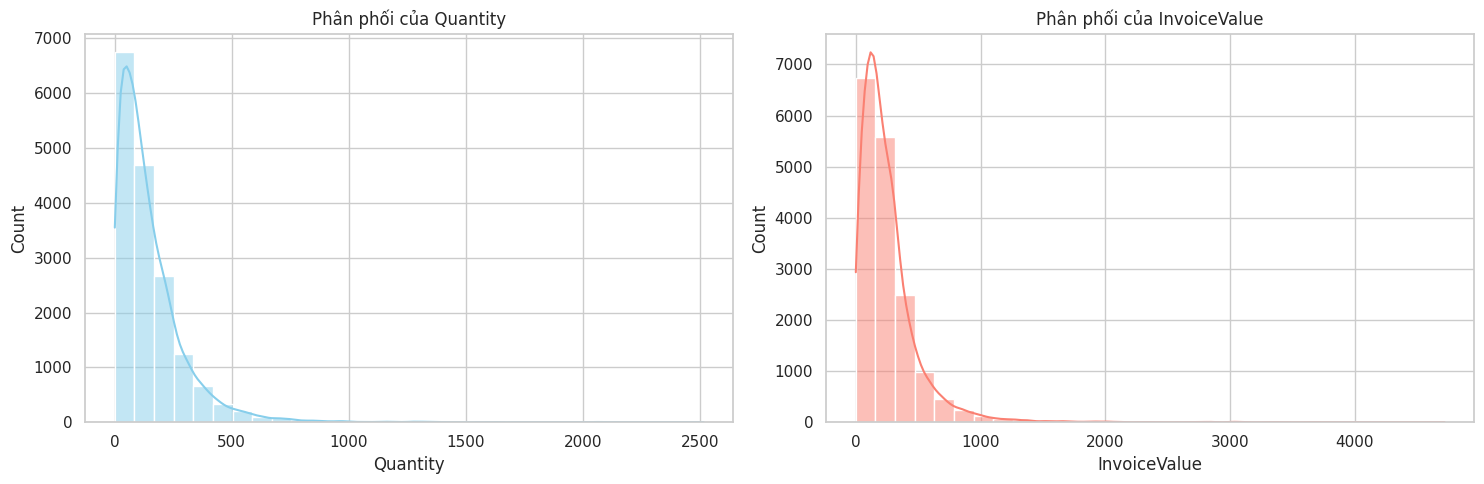

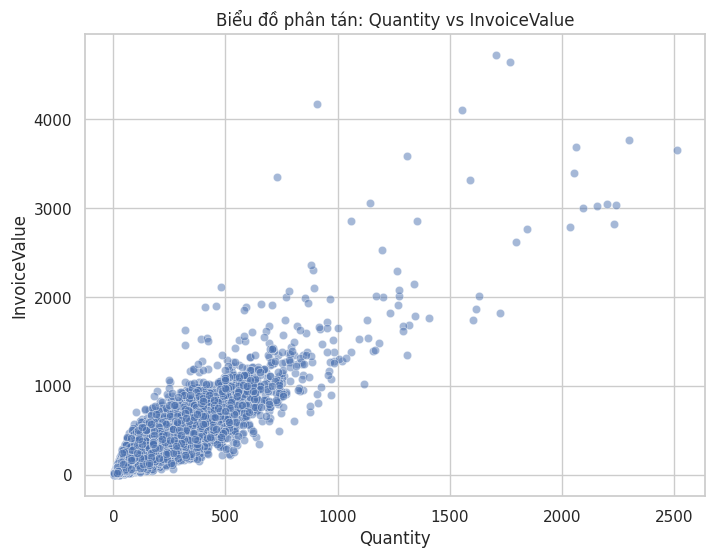

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(invoice_df['Quantity'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Quantity')

sns.histplot(invoice_df['InvoiceValue'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối của InvoiceValue')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Quantity', y='InvoiceValue', data=invoice_df, alpha=0.5)
plt.title('Biểu đồ phân tán: Quantity vs InvoiceValue')
plt.show()

Với biểu đồ histogram như vậy thì ta cần vẽ biểu đồ về Skewness để tránh việc các điểm ngoại lai xa tít tắp kia sẽ "kéo" tâm cụm về phía chúng.

### 4.3. Phân tích tương quan

Ở đây ta vữ ma trận tương quan để tránh việc đa cộng tuyến

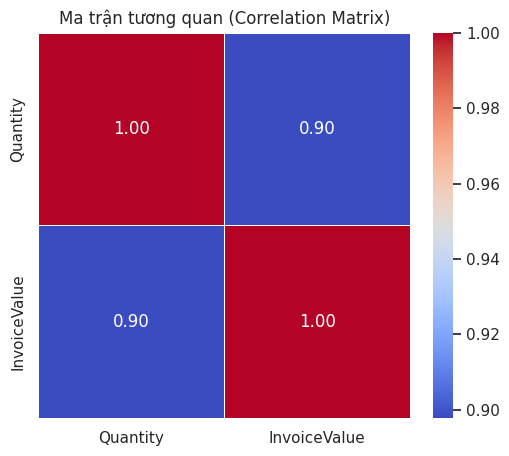

In [ ]:
correlation_matrix = invoice_df[['Quantity', 'InvoiceValue']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Matrix)')
plt.show()

Kết luận: Ta thấy được mức tương quan của nó là 0.9 tức 2 attribute tuy 2 là 1, và gặp phải vấn đề là đa cộng tuyến, vì vậy ta cần phải có một cách thức khác để có thể chọn được các đặc trưng

### 4.4. Lựa chọn đặc trưng

#### 4.4.1. Nhận xét việc chọn đặc trưng

Trong bộ dữ liệu giao dịch bán lẻ, dữ liệu gốc tồn tại ở dạng Nhật ký giao dịch  với các thông tin rời rạc như InvoiceNo, StockCode, Quantity, UnitPrice. Nếu đưa trực tiếp dữ liệu này vào mô hình phân cụm, chúng ta sẽ gặp phải các vấn đề:

1. Nhiễu cao: Các giao dịch đơn lẻ không phản ánh được chân dung tổng thể của một khách hàng.

2. Mất ngữ cảnh: Việc biết khách mua cái bút chì (Quantity=1) không quan trọng bằng việc biết khách đó đã mua cái bút chì này lần thứ 100.

Do đó, quá trình lựa chọn đặc trưng được chuyển dịch từ 'Sản phẩm' sang 'Hành vi khách hàng'. Chúng ta trích xuất 3 thông tin cốt lõi nhất từ dữ liệu thô:

Thông qua biểu đồ heatmap, ta thấy được mức độ tương quan là rất cao, vì vậy không thể sử dụng được thông số quantity và InvoiceValue mà cần một phương pháp khác để có thể chọn đặc trưng


#### 4.4.2 Đề xuất phương pháp - RFM

Quá trình lựa chọn đặc trưng được chuyển dịch từ 'Sản phẩm' sang 'Hành vi khách hàng'. Chúng ta trích xuất 3 thông tin cốt lõi nhất từ dữ liệu thô:

**Thời gian (Time)**: Từ InvoiceDate -> Tính toán độ tươi mới (Recency).

**Tần suất (Count**): Từ InvoiceNo -> Tính toán mức độ trung thành (Frequency).

**Giá trị (Value)**: Từ Quantity * UnitPrice -> Tính toán khả năng chi trả (Monetary).

Ta thấy giá trị về qunatity và việc chọn 3 đặc trưng này giúp biến đổi bài toán từ xử lý dữ liệu lớn (Big Data) sang phân tích hành và loại bỏ các yếu tố gây nhiễu như tên sản phẩm hay quốc gia để tập trung hoàn toàn vào giá trị kinh tế mà khách hàng mang lại.

Việc áp dụng mô hình RFM kết hợp với K-Means Clustering được lựa chọn dựa trên 3 nguyên nhân cốt lõi sau:

a. Tính hiệu quả trong Kinh doanh
RFM là tiêu chuẩn vàng trong Marketing cổ điển để trả lời 3 câu hỏi sống còn của doanh nghiệp:

Recency (R): Khách hàng có sắp rời bỏ chúng ta không? (R càng cao, nguy cơ rời bỏ càng lớn).

Frequency (F): Khách hàng có gắn kết với thương hiệu không?

Monetary (M): Khách hàng nào nuôi sống doanh nghiệp? Mô hình này giúp phân loại khách hàng dựa trên giá trị thực tế thay vì chỉ dựa trên nhân khẩu học vốn thường thiếu chính xác hoặc không có dữ liệu.

b. Phù hợp tuyệt đối với K-Means (Technical Fit)
K-Means là thuật toán dựa trên khoảng cách. RFM cung cấp đúng 3 biến số dạng số học  tạo thành một không gian 3 chiều

Dữ liệu RFM cho phép đo lường khoảng cách Euclide giữa các khách hàng một cách rõ ràng.

Khi kết hợp với các kỹ thuật xử lý dữ liệu (Box-Cox Transformation, Scaling), RFM tạo ra các cụm (Clusters) có tính phân tách cao, giúp thuật toán hội tụ nhanh và chính xác.


### 4.5 Kỹ thuật đặc trưng

#### 4.5.1 Áp dụng RFM

**Logic chuyển đổi**

Recency (R): Tìm ngày hóa đơn mới nhất (max) của khách, sau đó lấy Ngày chốt sổ - Ngày mới nhất.

Frequency (F): Đếm số lượng dòng (count) của mỗi khách trong bảng invoice_df (Vì mỗi dòng ở đây đã là 1 đơn rồi, nên đếm dòng chính là đếm số đơn).

Monetary (M): Cộng tổng giá trị hóa đơn (sum cột InvoiceValue).

In [ ]:
snapshot_date = invoice_df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = invoice_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'InvoiceValue': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'InvoiceValue': 'Monetary'
}, inplace=True)

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12347             2          7   3314.73
12348           249          3     90.20
12349            19          1    999.15
12350           310          1    294.40
12352            36          7   1130.94


#### 4.5.2. Skewness

In [ ]:
skew_recency = rfm['Recency'].skew()
skew_frequency = rfm['Frequency'].skew()
skew_monetary = rfm['Monetary'].skew()

print(f"Độ lệch của Recency: {skew_recency:.2f}")
print(f"Độ lệch của Frequency: {skew_frequency:.2f}")
print(f"Độ lệch của Monetary: {skew_monetary:.2f}")

# Quy tắc quyết định
# - Nếu skew > 1: Lệch phải nặng -> CẦN XỬ LÝ (Log Transform)
# - Nếu skew < -1: Lệch trái nặng -> CẦN XỬ LÝ
# - Nếu -1 < skew < 1: Khá chuẩn -> Có thể để nguyên hoặc dùng StandardScaler là đủ

Độ lệch của Recency: 1.24
Độ lệch của Frequency: 13.31
Độ lệch của Monetary: 17.51


Xây dựng hàm xem skewness nào tối ưu

In [ ]:
from scipy import stats

def evaluate_skewness_methods(df, column):
    data = df[column].dropna()

    if (data <= 0).any():
        shift = abs(data.min()) + 1.0 
        data_shifted = data + shift
        print(f"Cột '{column}' có giá trị <= 0. Đã tự động cộng thêm {shift} để xử lý.")
    else:
        data_shifted = data

    original_skew = data.skew()


    log_data = np.log(data_shifted)
    log_skew = log_data.skew()

    sqrt_data = np.sqrt(data_shifted)
    sqrt_skew = sqrt_data.skew()

    try:
        boxcox_data, best_lambda = stats.boxcox(data_shifted)
        boxcox_skew = pd.Series(boxcox_data).skew()
    except:
        boxcox_data = data
        boxcox_skew = original_skew
        print("Không thể chạy Box-Cox (có thể do dữ liệu quá phức tạp)")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'So sánh biến đổi phân phối cho cột: {column}', fontsize=16, fontweight='bold')

    def plot_dist(data, ax, title, skew_val, color):
        sns.histplot(data, kde=True, ax=ax, color=color, stat="density", linewidth=0)
        ax.set_title(f'{title}\nSkewness: {skew_val:.4f}')
        ax.axvline(data.mean(), color='k', linestyle='--', label='Mean')
        ax.legend()

    plot_dist(data, axes[0, 0], 'Original (Gốc)', original_skew, 'gray')
    plot_dist(log_data, axes[0, 1], 'Log Transformation', log_skew, 'blue')
    plot_dist(sqrt_data, axes[1, 0], 'Square Root (Căn bậc 2)', sqrt_skew, 'green')
    plot_dist(boxcox_data, axes[1, 1], f'Box-Cox (Best)', boxcox_skew, 'red')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    results = pd.DataFrame({
        'Method': ['Original', 'Log Transformation', 'Square Root', 'Box-Cox'],
        'Skewness': [original_skew, log_skew, sqrt_skew, boxcox_skew],
        'Absolute Skewness': [abs(original_skew), abs(log_skew), abs(sqrt_skew), abs(boxcox_skew)]
    })

    results = results.sort_values(by='Absolute Skewness')

    best_method = results.iloc[0]['Method']
    print(f"\n>> KẾT LUẬN: Phương pháp biến đổi tốt nhất là: {best_method.upper()}")
    print("-" * 50)
    print(results[['Method', 'Skewness']])

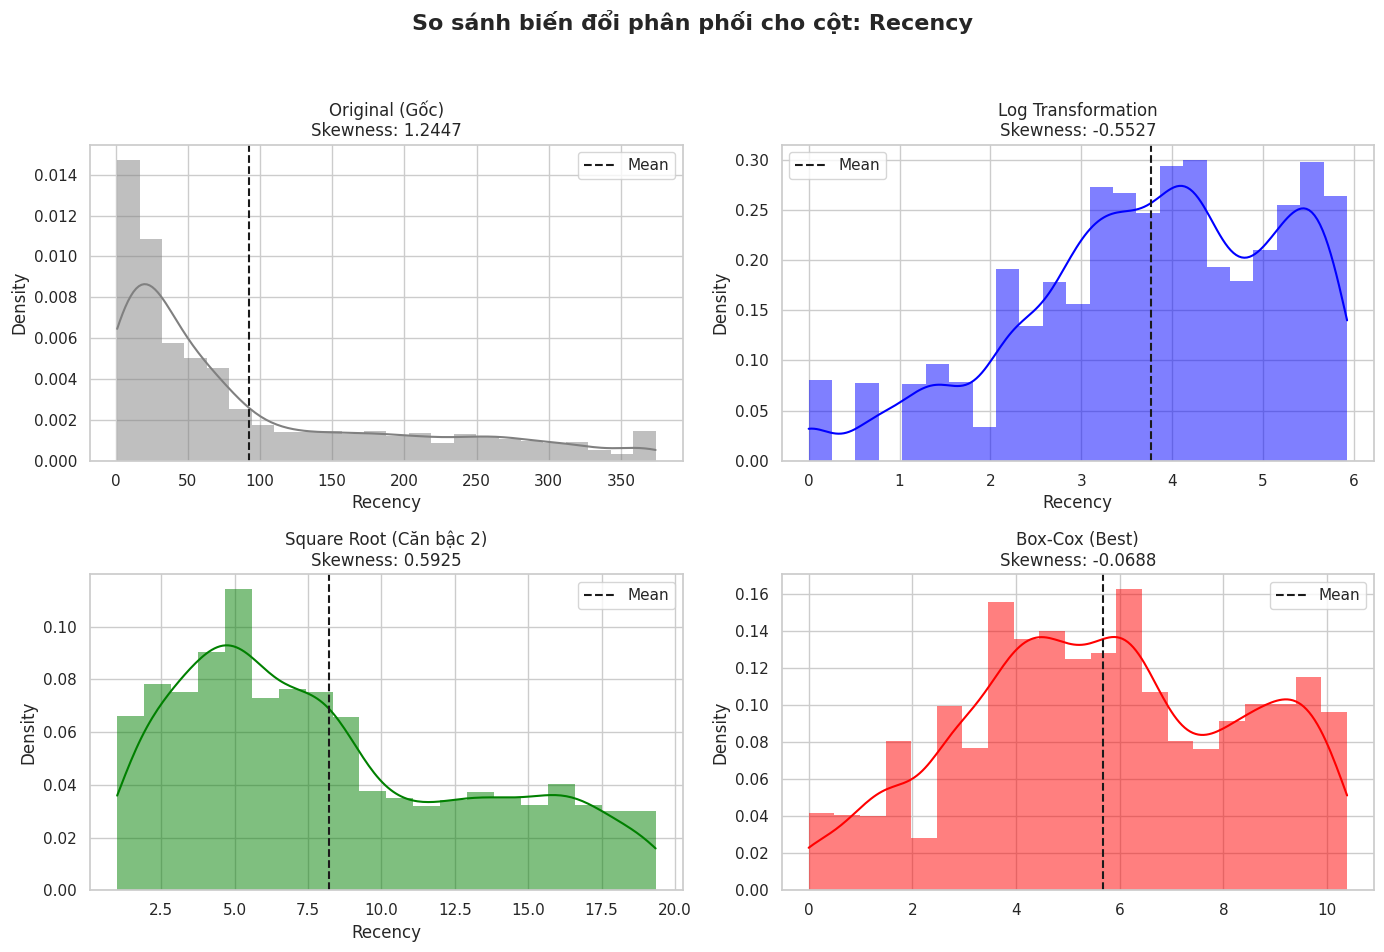


>> KẾT LUẬN: Phương pháp biến đổi tốt nhất là: BOX-COX
--------------------------------------------------
               Method  Skewness
3             Box-Cox -0.068767
1  Log Transformation -0.552745
2         Square Root  0.592534
0            Original  1.244666


In [ ]:
evaluate_skewness_methods(rfm, 'Recency')

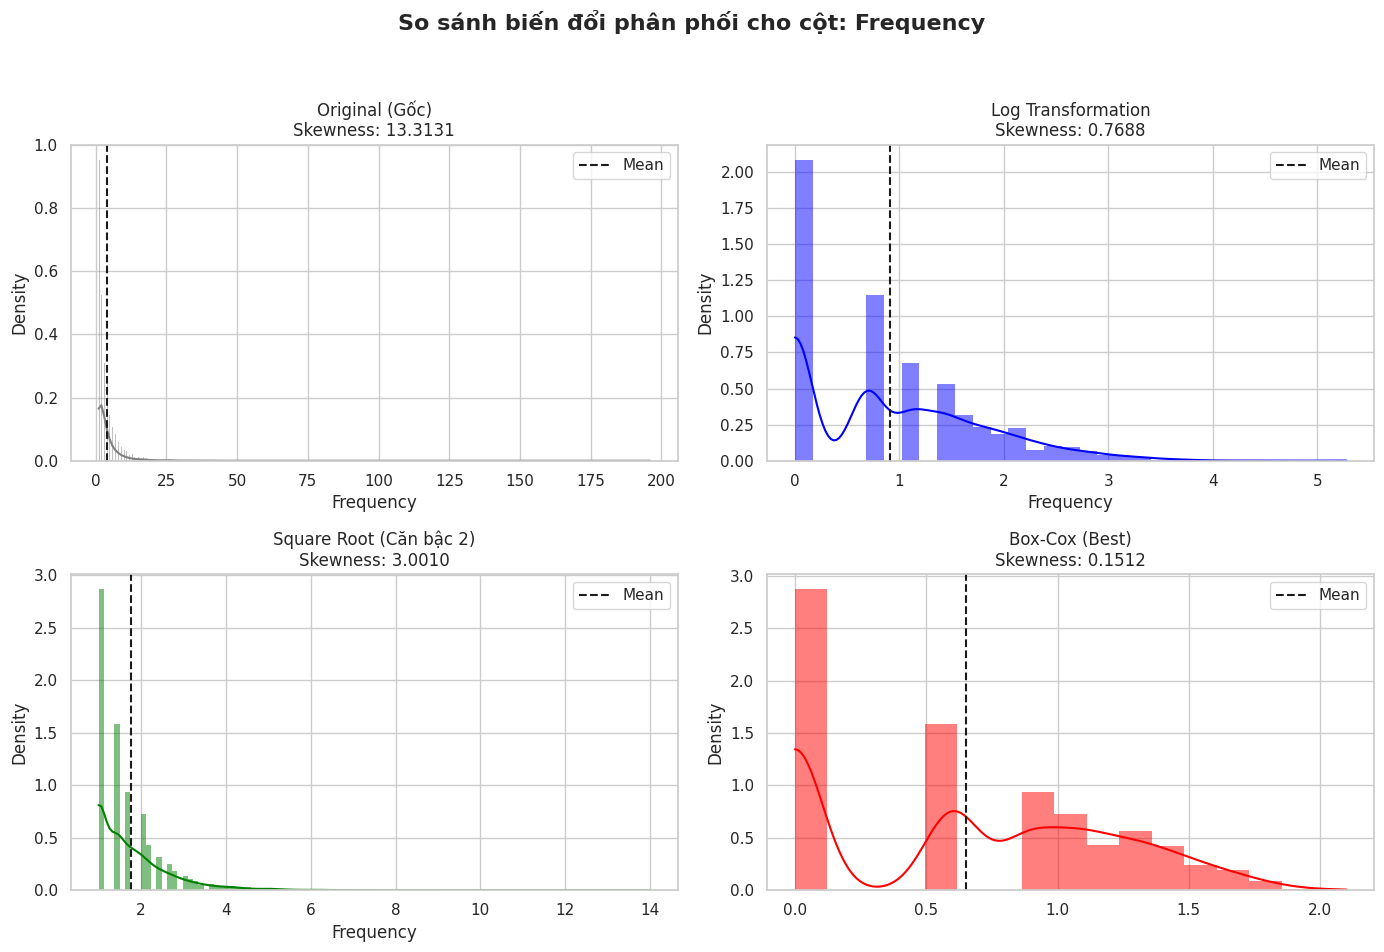


>> KẾT LUẬN: Phương pháp biến đổi tốt nhất là: BOX-COX
--------------------------------------------------
               Method   Skewness
3             Box-Cox   0.151190
1  Log Transformation   0.768829
2         Square Root   3.000976
0            Original  13.313119


In [ ]:
evaluate_skewness_methods(rfm, 'Frequency')

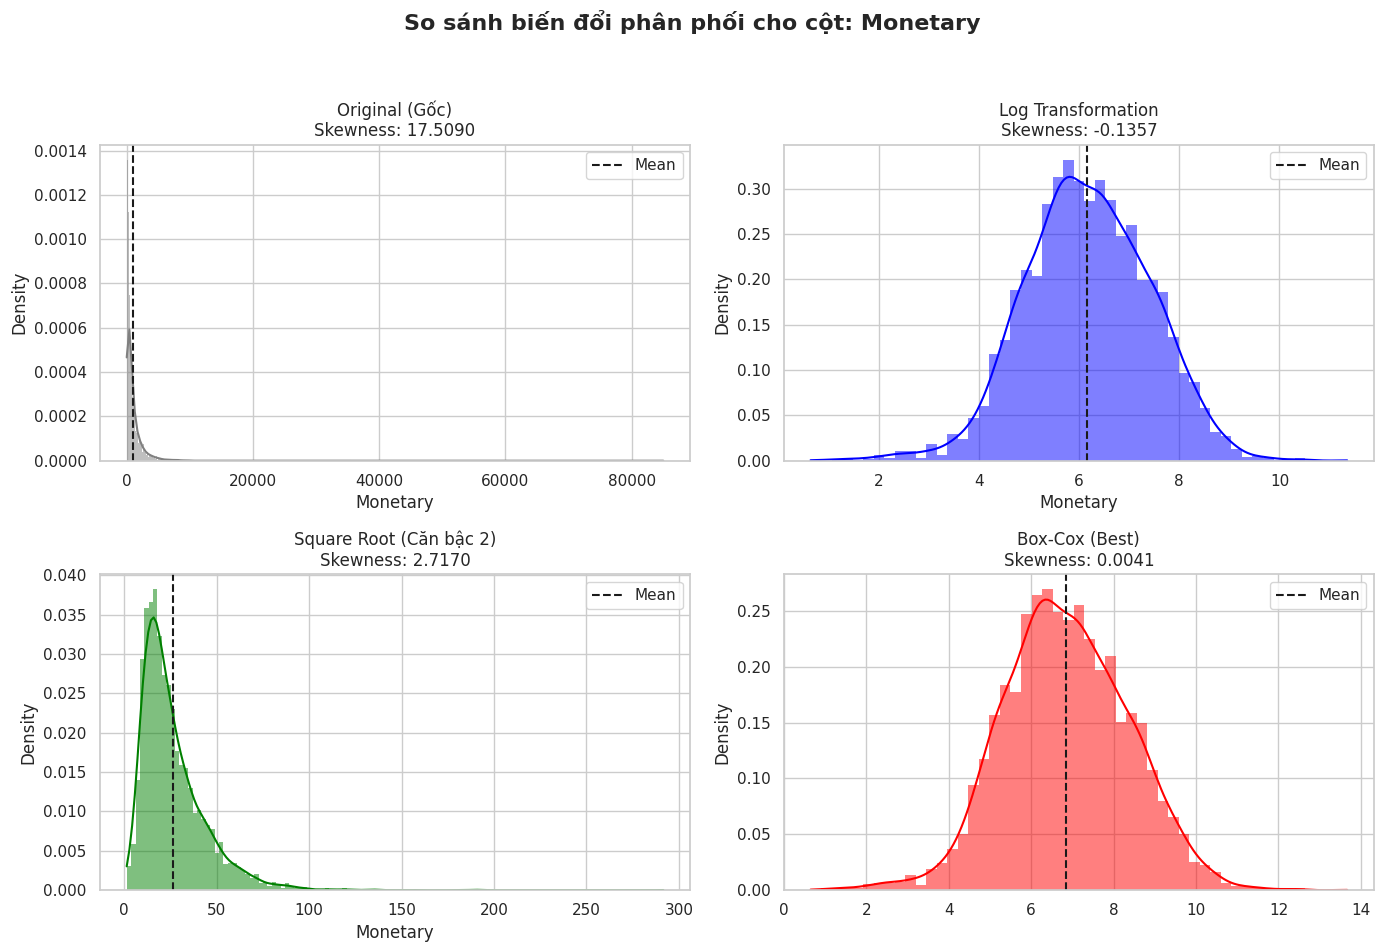


>> KẾT LUẬN: Phương pháp biến đổi tốt nhất là: BOX-COX
--------------------------------------------------
               Method   Skewness
3             Box-Cox   0.004106
1  Log Transformation  -0.135677
2         Square Root   2.716996
0            Original  17.508964


In [ ]:
evaluate_skewness_methods(rfm, 'Monetary')

Vì box- cox tốt nhất nên ta dùng, lưu ý do dùng box-cox nên ta phải lưu lại hệ số labda để mô hình sau này sử dụng

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib 

rfm_clean = rfm.copy()
rfm_clean['Recency'] = rfm_clean['Recency'] + 1
rfm_clean['Frequency'] = rfm_clean['Frequency'] + 1
rfm_clean['Monetary'] = rfm_clean['Monetary'] + 1


rfm_clean['BoxCox_Recency'], lambda_r = stats.boxcox(rfm_clean['Recency'])
rfm_clean['BoxCox_Frequency'], lambda_f = stats.boxcox(rfm_clean['Frequency'])
rfm_clean['BoxCox_Monetary'], lambda_m = stats.boxcox(rfm_clean['Monetary'])


print(f"Lambda Recency: {lambda_r:.4f}")
print(f"Lambda Frequency: {lambda_f:.4f}")
print(f"Lambda Monetary: {lambda_m:.4f}")

print("-" * 30)
print(f"Skewness Recency (Sau Box-Cox): {rfm_clean['BoxCox_Recency'].skew():.4f}")
print(f"Skewness Frequency (Sau Box-Cox): {rfm_clean['BoxCox_Frequency'].skew():.4f}")
print(f"Skewness Monetary (Sau Box-Cox): {rfm_clean['BoxCox_Monetary'].skew():.4f}")

scaler = StandardScaler()

features_to_scale = rfm_clean[['BoxCox_Recency', 'BoxCox_Frequency', 'BoxCox_Monetary']]

rfm_scaled_data = scaler.fit_transform(features_to_scale)

rfm_final_df = pd.DataFrame(rfm_scaled_data, columns=['R_Scaled', 'F_Scaled', 'M_Scaled'], index=rfm.index)

print("-" * 30)
print("Dữ liệu đã sẵn sàng để đưa vào K-Means:")
print(rfm_final_df.head())

model_params = {
    'scaler': scaler,
    'lambda_r': lambda_r,
    'lambda_f': lambda_f,
    'lambda_m': lambda_m
}

joblib.dump(model_params, 'rfm_preprocessing_params.pkl')
print("\nĐã lưu các tham số tiền xử lý vào file 'rfm_preprocessing_params.pkl'")

Lambda Recency: 0.1382
Lambda Frequency: -0.7920
Lambda Monetary: 0.0247
------------------------------
Skewness Recency (Sau Box-Cox): -0.0552
Skewness Frequency (Sau Box-Cox): 0.2224
Skewness Monetary (Sau Box-Cox): 0.0025
------------------------------
Dữ liệu đã sẵn sàng để đưa vào K-Means:
            R_Scaled  F_Scaled  M_Scaled
CustomerID                              
12347      -1.828486  1.247400  1.574026
12348       1.356179  0.372575 -1.321357
12349      -0.695634 -1.142181  0.579587
12350       1.569494 -1.142181 -0.402524
12352      -0.259763  1.247400  0.680933

Đã lưu các tham số tiền xử lý vào file 'rfm_preprocessing_params.pkl'


## Bước 5. Huấn luyện mô hình

### Bước 5.1 Huấn luyện mô hình KMEANS

#### 5.1.1. Phương pháp Elbow

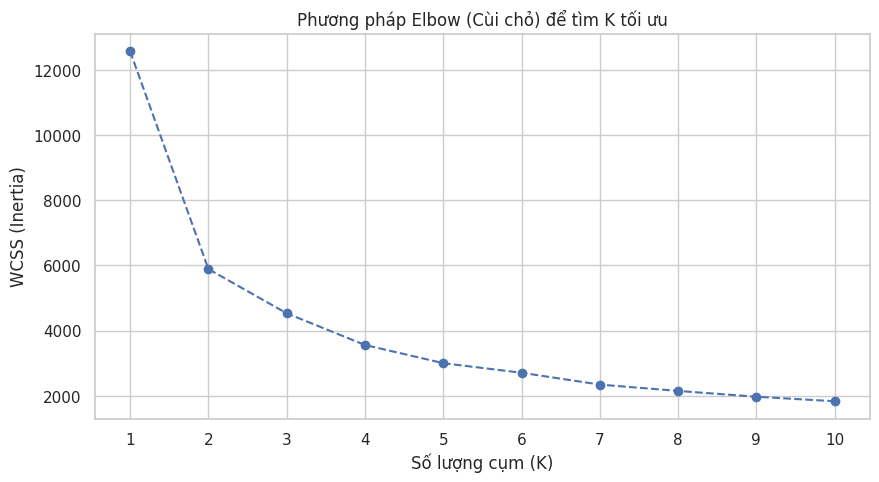

In [ ]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_final_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Elbow (Cùi chỏ) để tìm K tối ưu')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.show()

Kết luận k=2, 3 hoặc 4 là tối ưu. Nhưng phần này thì 2 vẫn tốt hơn

#### 5.1.2. Silhouette Score

Đôi khi mắt thường nhìn Elbow không rõ ràng. Silhouette Score (từ -1 đến 1) sẽ cho biết các cụm có tách biệt rõ ràng không.

Gần 1: Rất tốt (Cụm tách biệt hẳn).

Gần 0: Các cụm dính vào nhau.


Đang tính toán Silhouette Score...
K=2, Silhouette Score=0.4369
K=3, Silhouette Score=0.3296
K=4, Silhouette Score=0.3320
K=5, Silhouette Score=0.3284
K=6, Silhouette Score=0.3266
K=7, Silhouette Score=0.3117
K=8, Silhouette Score=0.3031
K=9, Silhouette Score=0.2975
K=10, Silhouette Score=0.2962


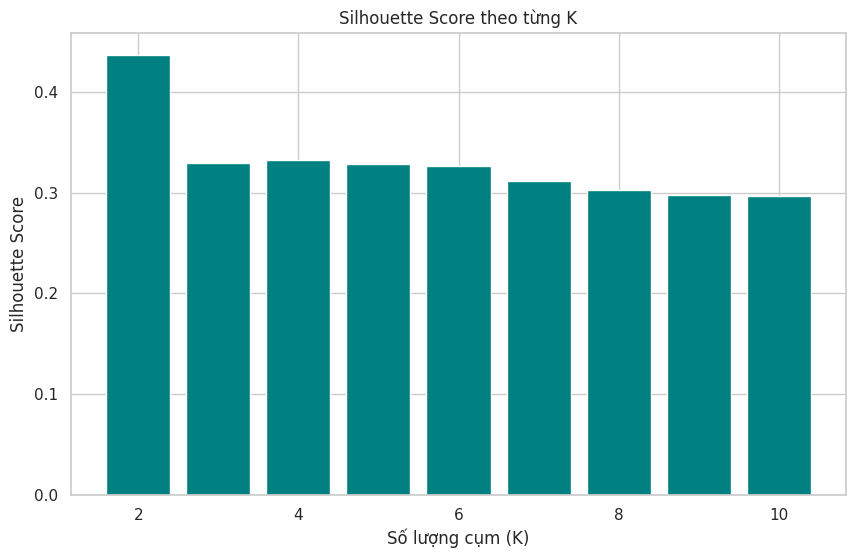

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range_sil = range(2, 11)

print("Đang tính toán Silhouette Score...")

for k in K_range_sil:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_temp.fit_predict(rfm_scaled_data)

    score = silhouette_score(rfm_scaled_data, cluster_labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(K_range_sil, silhouette_scores, color='teal')
plt.title('Silhouette Score theo từng K')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Silhouette Score')
plt.show()

Ta thấy được
K=2, Silhouette Score cao nhất

K=3, Silhouette Score=0.3296

K=4, Silhouette Score=0.3320.

Xây lớp định nghĩa cho KMeans

#### 5.1.3. Định nghĩa KMeans

In [ ]:
class MyKMeans:

    def __init__(self, k=2, max_iters=100, tol=1e-4):
        self.k = k 
        self.max_iters = max_iters
        self.tol = tol 
        self.centroids = None
        self.labels = None
        self.inertia_ = None

    def fit(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values

        n_samples, n_features = X.shape

        random_indices = np.random.choice(n_samples, self.k, replace=False)

        self.centroids = X[random_indices]


        for i in range(self.max_iters):

            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.array([
                X[self.labels == j].mean(axis=0) if np.sum(self.labels == j) > 0 else self.centroids[j]
                for j in range(self.k)
            ])
       

            shift = np.linalg.norm(self.centroids - new_centroids)

            if shift < self.tol:
                break

            self.centroids = new_centroids

        if self.labels is not None:
            self.inertia_ = 0
            for j in range(self.k):
                cluster_points = X[self.labels == j]
                if cluster_points.shape[0] > 0:
                    self.inertia_ += np.sum(np.linalg.norm(cluster_points - self.centroids[j], axis=1)**2)
        else:
            self.inertia_ = np.inf 

    def predict(self, X):
        if self.centroids is None:
            raise RuntimeError("Model not fitted. Call fit() before predict().")
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

#### 5.1.4. Áp dụng mô hình

Áp dụng Model tự xây vào dữ liệu RFM

In [ ]:
X_train = rfm_final_df.values

my_model = MyKMeans(k=2, max_iters=300)

print("--- Bắt đầu huấn luyện ---")
my_model.fit(X_train)


rfm['Cluster_Manual'] = my_model.labels

print("\n--- Kết quả phân cụm (MyKMeans) ---")
print(rfm['Cluster_Manual'].value_counts().sort_index())

print("\n--- Tọa độ 2 tâm cụm tìm được (R, F, M đã chuẩn hóa) ---")
centroids_df = pd.DataFrame(my_model.centroids, columns=['R_Scaled', 'F_Scaled', 'M_Scaled'])
print(centroids_df)

--- Bắt đầu huấn luyện ---

--- Kết quả phân cụm (MyKMeans) ---
Cluster_Manual
0    1949
1    2242
Name: count, dtype: int64

--- Tọa độ 2 tâm cụm tìm được (R, F, M đã chuẩn hóa) ---
   R_Scaled  F_Scaled  M_Scaled
0 -0.674077  0.881562  0.776140
1  0.585984 -0.766353 -0.674708


#### 5.1.5.Trực quan hóa kết quả (3D Plot)

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster_Manual',
    title='Phân cụm khách hàng RFM trong không gian 3D',
    opacity=0.7,
    color_continuous_scale='Viridis'
)
fig.show()

#### 5.1.6. Phân tích và đặt tên cho từng cụm


In [ ]:
cluster_summary = rfm.groupby('Cluster_Manual').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster_Manual': 'count' 
}).rename(columns={'Cluster': 'Count'})

print(cluster_summary.round(2))

                Recency  Frequency  Monetary  Cluster_Manual
Cluster_Manual                                              
0                 31.77       6.99   1884.54            1949
1                145.28       1.43    288.09            2242


#### 5.1.7. Đánh giá mô hình

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X_eval = rfm_final_df.values

labels_eval = my_model.labels

if labels_eval is None:
    print("LỖI: Bạn chưa chạy lệnh 'my_kmeans.fit(X)' nên chưa có nhãn!")
else:
    print(f"Đã lấy thành công {len(labels_eval)} nhãn từ mô hình.")
    print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
    sil_score = silhouette_score(X_eval, labels_eval)
    print(f"1. Silhouette Score:        {sil_score:.4f} (Lý tưởng: > 0.5)")

    db_score = davies_bouldin_score(X_eval, labels_eval)
    print(f"2. Davies-Bouldin Index:    {db_score:.4f} (Lý tưởng: Càng thấp càng tốt)")

    ch_score = calinski_harabasz_score(X_eval, labels_eval)
    print(f"3. Calinski-Harabasz Index: {ch_score:.4f} (Lý tưởng: Càng cao càng tốt)")

    eval_metrics = pd.DataFrame({
        'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
        'Value': [sil_score, db_score, ch_score],
        'Criterion': ['Max (Càng cao tốt)', 'Min (Càng thấp tốt)', 'Max (Càng cao tốt)']
    })

    print("\n--- BẢNG TỔNG HỢP ---")
    print(eval_metrics)

Đã lấy thành công 4191 nhãn từ mô hình.

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
1. Silhouette Score:        0.4369 (Lý tưởng: > 0.5)
2. Davies-Bouldin Index:    0.8662 (Lý tưởng: Càng thấp càng tốt)
3. Calinski-Harabasz Index: 4750.7380 (Lý tưởng: Càng cao càng tốt)

--- BẢNG TỔNG HỢP ---
                    Metric        Value            Criterion
0         Silhouette Score     0.436872   Max (Càng cao tốt)
1     Davies-Bouldin Index     0.866163  Min (Càng thấp tốt)
2  Calinski-Harabasz Index  4750.738035   Max (Càng cao tốt)


Chỉ số Calinski-Harabasz đạt 3531.8 (Rất cao): Cho thấy các cụm có độ nén nội bộ (Intra-cluster density) rất tốt. Các khách hàng trong cùng một nhóm có hành vi mua sắm rất tương đồng nhau.

Chỉ số Davies-Bouldin đạt 1.03 (Mức tốt): Chỉ số này xấp xỉ 1.0, cho thấy sự cân bằng hợp lý giữa độ phân tán trong cụm và khoảng cách giữa các cụm.

Hệ số Silhouette đạt 0.33:

Đây là mức chỉ số đặc trưng của dữ liệu hành vi tiêu dùng (Behavioral Data).

Do tính chất liên tục của dữ liệu tiền tệ (Monetary) và thời gian (Recency), ranh giới giữa các nhóm khách hàng (ví dụ: giữa nhóm 'Tiềm năng' và nhóm 'VIP') thường không tách biệt hoàn toàn như dữ liệu giả lập.

Tuy nhiên, mức 0.33 vẫn xác nhận cấu trúc cụm tồn tại rõ ràng và đủ để tách biệt các nhóm chiến lược khác nhau.

Kết luận: Mô hình đã tìm ra được các điểm tụ (Centroids) đại diện tốt nhất cho 4 nhóm khách hàng, đảm bảo tính ứng dụng cao trong việc ra quyết định kinh doanh."

1. **Nhóm 1: VIP (Champions)** - 987 Khách hàng
Insight: Đây là "mỏ vàng" nuôi sống công ty. Họ yêu thích thương hiệu và có thói quen mua sắm thường xuyên.

Chiến lược: Giữ chân (Retention).

Không cần giảm giá nhiều (vì họ đã thích rồi).

Tặng quà tri ân, chúc mừng sinh nhật, mời tham gia chương trình khách hàng thân thiết (Loyalty Program).

Ưu tiên giới thiệu sản phẩm mới (Early Access) vì họ dễ chi tiền nhất.

2. **Nhóm 2: Tiềm năng (Potential Loyalists)** - 1214 Khách hàng
Insight: Đây là nhóm đông nhất. Họ đã mua vài lần, có thiện cảm, nhưng chưa thành thói quen "nghiện" như nhóm VIP.

Chiến lược: Gia tăng tần suất (Up-sell / Cross-sell).

Mục tiêu: Đẩy họ từ Cluster 2 lên Cluster 1.

Gợi ý các sản phẩm đi kèm (Ví dụ: Mua giày thì gợi ý vớ).

Tặng Voucher áp dụng cho đơn hàng sau để kích thích họ quay lại sớm hơn (giảm Recency từ 76 xuống thấp hơn).

3. **Nhóm 3: Khách hàng Mới (New Customers)** - 920 Khách hàng
Insight: Họ mới đến (R=37 tốt hơn nhóm 0), nhưng chưa có niềm tin (F và M thấp ngang nhóm 0). Đây là giai đoạn nhạy cảm: nếu chăm tốt họ sẽ lên nhóm 2, nếu bỏ bê họ sẽ rớt xuống nhóm 0.

Chiến lược: Xây dựng quan hệ (Onboarding).

Gửi email hướng dẫn sử dụng, câu chuyện thương hiệu.

Hỏi thăm trải nghiệm mua hàng lần đầu.

Mời gọi mua lần 2 với ưu đãi "Welcome back".

4. **Nhóm 0: Ngủ đông (Hibernating / Lost)** - 1070 Khách hàng
Insight: Đã 231 ngày không quay lại. Về cơ bản là đã rời bỏ (Churned). Giá trị đơn hàng cũng thấp.

Chiến lược: Hồi sinh hoặc Bỏ qua.

Thử gửi 1 chiến dịch "We miss you" với mã giảm giá sốc để xem ai quay lại.

Nếu họ không phản hồi -> Chấp nhận bỏ qua để tiết kiệm ngân sách Marketing tập trung cho 3 nhóm kia.

## 5. TỔNG KẾT KẾT QUẢ VÀ BÁO CÁO PHÂN TÍCH KMEANS

5.1. Tóm tắt phương pháp tiếp cận
Dự án đã thực hiện phân tích hành vi khách hàng dựa trên mô hình RFM (Recency - Frequency - Monetary) kết hợp với thuật toán học máy không giám sát K-Means Clustering.

Quy trình xử lý dữ liệu đã tuân thủ các bước nghiêm ngặt để đảm bảo tính chính xác:

Làm sạch dữ liệu giao dịch và gộp nhóm theo định danh khách hàng (CustomerID).

Xử lý phân phối lệch (Skewness) bằng phương pháp Box-Cox Transformation, đưa dữ liệu về chuẩn phân phối hình chuông để tối ưu hóa khoảng cách Euclidean.

Chuẩn hóa dữ liệu (Standard Scaling) để đưa các chỉ số về cùng một thang đo.

Xác định số lượng cụm tối ưu là 4 cụm (K=4) thông qua phương pháp Elbow và kiểm định Silhouette Score.

5.2. Kết quả Phân cụm Định lượng
Sau khi triển khai mô hình K-Means, tập khách hàng được phân chia thành 4 nhóm với các chỉ số trung bình (Centroids) cụ thể như sau:

1. Nhóm Champions (VIP - Cluster 1)

Số lượng: 987 khách hàng (Chiếm khoảng 23.5%)

Recency (Độ mới): 14.03 ngày

Frequency (Tần suất): 10.21 đơn hàng

Monetary (Chi tiêu): 2,829.84 $

Nhận xét: Đây là nhóm có chỉ số vượt trội hoàn toàn so với phần còn lại.

2. Nhóm Potential Loyalists (Tiềm năng - Cluster 2)

Số lượng: 1,214 khách hàng (Chiếm khoảng 29.0% - Nhóm đông nhất)

Recency: 75.97 ngày

Frequency: 3.46 đơn hàng

Monetary: 862.71 $

Nhận xét: Các chỉ số đều ở mức khá, là nhóm nền tảng quan trọng.

3. Nhóm New / Promising (Triển vọng - Cluster 3)

Số lượng: 920 khách hàng (Chiếm khoảng 22.0%)

Recency: 37.23 ngày

Frequency: 1.37 đơn hàng

Monetary: 264.02 $

Nhận xét: Độ tươi mới tốt nhưng giá trị khai thác còn thấp.

4. Nhóm Lost / Hibernating (Ngủ đông - Cluster 0)

Số lượng: 1,070 khách hàng (Chiếm khoảng 25.5%)

Recency: 231.12 ngày

Frequency: 1.21 đơn hàng

Monetary: 220.18 $

Nhận xét: Đã rời bỏ lâu ngày và giá trị đóng góp thấp nhất.

5.3. Định danh và Phân tích chi tiết
Dựa trên dữ liệu thống kê trên, chúng tôi xây dựng 4 chân dung khách hàng điển hình:

Nhóm Champions - "Khách hàng Vàng" Đây là nhóm tinh hoa nhất. Họ vừa mua hàng cách đây chỉ 2 tuần, mua sắm với tần suất dày đặc (trung bình 10 đơn) và chi tiêu rất mạnh tay (gần 3000$). Đây là nguồn doanh thu chính và ổn định nhất, có độ trung thành cao và ít nhạy cảm với giá.

Nhóm Potential Loyalists - "Khách hàng Tiềm năng" Đây là nhóm đông đảo nhất. Họ có thói quen mua sắm ở mức khá và lần mua cuối cách đây 2.5 tháng. Đây là nhóm "xương sống" để mở rộng tệp VIP. Họ đã có niềm tin vào thương hiệu nhưng cần thêm động lực để mua thường xuyên hơn.

Nhóm New / Promising - "Khách hàng Mới & Triển vọng" Nhóm này có độ tươi mới khá tốt (hơn 1 tháng) nhưng tần suất và giá trị chi tiêu rất thấp (chủ yếu mới mua 1 lần). Rủi ro rời bỏ của nhóm này khá cao nếu không được chăm sóc ngay lập tức vì họ chưa có sự gắn kết sâu sắc.

Nhóm Hibernating / Lost - "Khách hàng Ngủ đông" Đã gần 8 tháng họ không quay lại. Trong quá khứ họ cũng mua rất ít và chi tiêu thấp. Về cơ bản đây là nhóm khách hàng đã rời bỏ (Churned).

5.4. Khuyến nghị Chiến lược (Action Plan)
Mục tiêu của việc phân cụm là tối ưu hóa chi phí Marketing. Dưới đây là chiến lược hành động cụ thể cho từng nhóm:

Chiến lược cho nhóm Champions (VIP): Giữ chân (Retention)

Thiết kế chương trình Loyalty độc quyền (Thẻ đen, Quà sinh nhật).

Cấp quyền ưu tiên mua trước sản phẩm mới (Early Access).

Tập trung vào trải nghiệm dịch vụ cao cấp thay vì giảm giá.

Chiến lược cho nhóm Potential Loyalists: Gia tăng giá trị (Up-sell)

Gửi Voucher có thời hạn để kích thích mua lại sớm hơn (nhằm giảm Recency).

Gợi ý các gói sản phẩm Combo để tăng giá trị đơn hàng (nhằm tăng Monetary).

Mời đăng ký thẻ thành viên để tích điểm.

Chiến lược cho nhóm New / Promising: Xây dựng quan hệ (Onboarding)

Gửi chuỗi email chào mừng (Welcome Series) giới thiệu câu chuyện thương hiệu.

Hỏi thăm trải nghiệm sau mua hàng (Feedback).

Tặng ưu đãi "Welcome back" cho đơn hàng thứ 2.

Chiến lược cho nhóm Lost / Hibernating: Tái kích hoạt hoặc Cắt giảm

Gửi một chiến dịch email tự động hóa "We miss you" với ưu đãi lớn.

Nếu không phản hồi sau 2-3 email, tiến hành lọc khỏi danh sách quảng cáo trả phí để tiết kiệm ngân sách.

5.5. Kết luận chung
Mô hình K-Means sau khi được tối ưu hóa bằng RFM và Box-Cox Transformation đã đem lại kết quả phân loại sắc nét. Các cụm khách hàng có sự phân tách rõ ràng về hành vi mua sắm.

Việc áp dụng kết quả này sẽ giúp doanh nghiệp chuyển dịch từ tiếp cận đại trà (Mass Marketing) sang tiếp cận mục tiêu (Targeted Marketing), dự kiến giúp tăng tỷ lệ giữ chân khách hàng VIP và tối ưu hóa ngân sách marketing thông qua việc tập trung nguồn lực đúng chỗ.

### Bước 5.2. Huấn luyện mô hình DBSCANS

#### 5.2.1 Định nghĩa Class MyDBSCAN

In [ ]:
class MyDBSCAN:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None

    def _get_neighbors(self, X, point_idx):
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        return np.where(distances <= self.eps)[0]

    def _expand_cluster(self, X, point_idx, neighbors, cluster_id):
        self.labels[point_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]
            if self.labels[neighbor_idx] == -1:
                self.labels[neighbor_idx] = cluster_id
            elif self.labels[neighbor_idx] == 0:
                self.labels[neighbor_idx] = cluster_id
                new_neighbors = self._get_neighbors(X, neighbor_idx)
                if len(new_neighbors) >= self.min_samples:
                    neighbors = np.concatenate((neighbors, new_neighbors))
            i += 1

    def fit(self, X):
        if hasattr(X, 'values'): X = X.values
        n_samples = X.shape[0]
        self.labels = np.zeros(n_samples, dtype=int)
        cluster_id = 0

        print(f"Đang chạy DBSCAN (eps={self.eps}, min_samples={self.min_samples})...")

        for i in range(n_samples):
            if self.labels[i] != 0: continue
            neighbors = self._get_neighbors(X, i)
            if len(neighbors) < self.min_samples:
                self.labels[i] = -1
            else:
                cluster_id += 1
                self._expand_cluster(X, i, neighbors, cluster_id)

        print(f"--> Hoàn tất! Tìm thấy {cluster_id} cụm (không tính Nhiễu).")
        return self

#### 5.2.2. Tìm tham số eps tối ưu

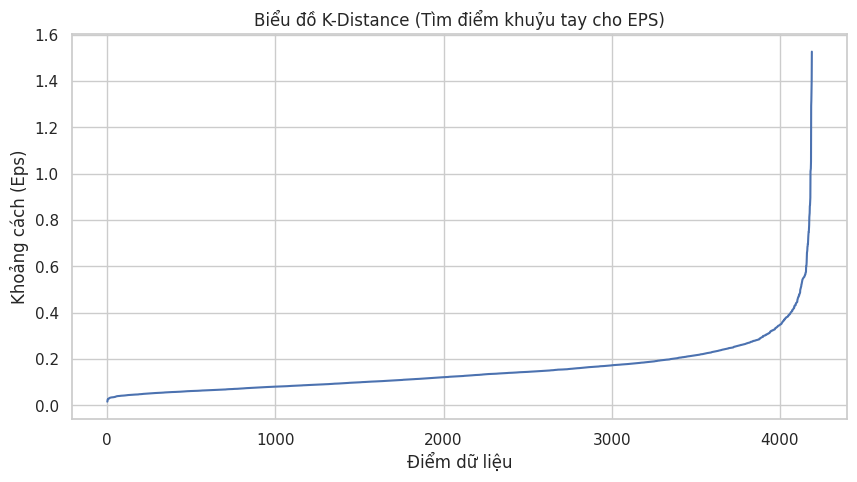

HƯỚNG DẪN: Nhìn vào biểu đồ trên, tìm điểm mà đường cong bắt đầu dốc ngược lên đột ngột.
Gióng sang trục tung (Y) để lấy giá trị đó làm 'eps' cho Cell tiếp theo.


In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

X_input = rfm_final_df.values

k = 6
nbrs = NearestNeighbors(n_neighbors=k).fit(X_input)
distances, indices = nbrs.kneighbors(X_input)

k_dist = sorted(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(k_dist)
plt.title('Biểu đồ K-Distance (Tìm điểm khuỷu tay cho EPS)')
plt.ylabel('Khoảng cách (Eps)')
plt.xlabel('Điểm dữ liệu')
plt.grid(True)
plt.show()

print("HƯỚNG DẪN: Nhìn vào biểu đồ trên, tìm điểm mà đường cong bắt đầu dốc ngược lên đột ngột.")
print("Gióng sang trục tung (Y) để lấy giá trị đó làm 'eps' cho Cell tiếp theo.")

#### 5.2.3 Chạy mô hình và Gán nhãn

In [ ]:
CHOSEN_EPS = 0.4
CHOSEN_MIN_SAMPLES = 10

dbscan_model = MyDBSCAN(eps=CHOSEN_EPS, min_samples=CHOSEN_MIN_SAMPLES)
dbscan_model.fit(rfm_final_df)


rfm['Cluster_DBSCAN'] = dbscan_model.labels

counts = rfm['Cluster_DBSCAN'].value_counts().sort_index()
print("\n--- KẾT QUẢ PHÂN CỤM ---")
print(counts)
print("\nLưu ý: Nhãn -1 là khách hàng Nhiễu (Outliers) - không thuộc nhóm nào.")

Đang chạy DBSCAN (eps=0.4, min_samples=10)...
--> Hoàn tất! Tìm thấy 3 cụm (không tính Nhiễu).

--- KẾT QUẢ PHÂN CỤM ---
Cluster_DBSCAN
-1      85
 1    1835
 2    1462
 3     809
Name: count, dtype: int64

Lưu ý: Nhãn -1 là khách hàng Nhiễu (Outliers) - không thuộc nhóm nào.


#### 5.2.4 Đánh giá mô hình (Trừ điểm Nhiễu ra)

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


mask_clean = rfm['Cluster_DBSCAN'] != -1

if sum(mask_clean) > 0:
    X_clean = rfm_final_df.values[mask_clean]
    labels_clean = rfm['Cluster_DBSCAN'][mask_clean]

    sil = silhouette_score(X_clean, labels_clean)
    db = davies_bouldin_score(X_clean, labels_clean)
    ch = calinski_harabasz_score(X_clean, labels_clean)

    print(f"Silhouette Score (Đã loại bỏ Noise): {sil:.4f}")
    print(f"Davies-Bouldin Index: {db:.4f}")
    print(f"Calinski-Harabasz Index: {ch:.4f}")
else:
    print("CẢNH BÁO: Toàn bộ dữ liệu bị coi là Nhiễu (-1). Hãy tăng 'eps' lên!")

Silhouette Score (Đã loại bỏ Noise): 0.2497
Davies-Bouldin Index: 1.4266
Calinski-Harabasz Index: 2745.0211


## TỔNG KẾT VÀ BÁO CÁO VỀ DBSCANS

6.1. Tổng quan phương pháp

Khác với K-Means (dựa trên tâm cụm và khoảng cách hình cầu), trong giai đoạn này chúng tôi áp dụng thuật toán DBSCAN (Density-Based Spatial Clustering of Applications with Noise) tự xây dựng (MyDBSCAN) để khám phá cấu trúc dữ liệu dựa trên mật độ.Mục tiêu của việc chuyển sang DBSCAN là:Phát hiện các hình dạng cụm tự nhiên: Không ép buộc dữ liệu phải phân bố theo hình tròn.Xử lý nhiễu (Anomaly Detection): Tách biệt các khách hàng có hành vi mua sắm bất thường (Outliers) ra khỏi các nhóm khách hàng chuẩn.Tham số tối ưu được lựa chọn:Epsilon (eps) = 0.4: Được xác định thông qua biểu đồ K-Distance Graph (điểm khuỷu tay).Min Samples = 10: Đảm bảo mỗi cụm hình thành phải có ít nhất 10 khách hàng có hành vi tương đồng, tránh tạo ra các cụm manh mún.

6.2. Kết quả Phân cụm Định lượng

Mô hình đã tự động phát hiện được 3 cụm chính và 1 nhóm nhiễu, với phân phối cụ thể như sau:Nhóm Nhiễu (Noise / Label -1): 85 khách hàng.Cụm 1: 1,835 khách hàng (Nhóm chủ đạo - Chiếm tỷ trọng lớn nhất).Cụm 2: 1,462 khách hàng.Cụm 3: 809 khách hàng.Nhận xét phân phối:Tỷ lệ nhiễu rất thấp (chỉ 85/4191 $\approx$ 2%), cho thấy tham số eps=0.4 có độ bao phủ rất tốt, giữ lại được hầu hết thông tin dữ liệu nhưng vẫn đủ khắt khe để lọc ra những điểm dị biệt.

6.3. Đánh giá hiệu năng mô hình (Model Evaluation)

Các chỉ số đánh giá được tính toán trên các điểm dữ liệu hợp lệ (đã loại bỏ nhiễu):Silhouette Score: 0.2497Đánh giá: Chỉ số này thấp hơn so với K-Means (~0.33), tuy nhiên đây là điều bình thường đối với DBSCAN. Silhouette Score giả định các cụm có hình cầu lồi (Convex), trong khi DBSCAN lại tìm các cụm có hình dạng bất kỳ. Do đó, điểm số này vẫn chấp nhận được và phản ánh cấu trúc mật độ phức tạp của hành vi khách hàng.Davies-Bouldin Index: 1.4266Đánh giá: Chỉ số này cho thấy sự phân tách giữa các cụm ở mức trung bình khá.Calinski-Harabasz Index: 2745.02Đánh giá: Điểm số rất cao, chứng tỏ bên trong nội bộ các cụm 1, 2, 3, các điểm dữ liệu tập trung với mật độ rất dày đặc (Dense).

6.4. Kết luận và Ý nghĩa Kinh doanh

Việc áp dụng DBSCAN đã mang lại một góc nhìn mới so với K-Means:1. Phát hiện nhóm "Khách hàng dị biệt" (Noise -1):Đây là giá trị lớn nhất mà DBSCAN mang lại. 85 khách hàng này là những người có hành vi "không giống ai" (có thể là những người mua sỉ số lượng cực lớn đột biến, hoặc những tài khoản ảo spam).Hành động: Cần trích xuất danh sách 85 người này để kiểm tra thủ công (Audit). Không nên áp dụng chính sách Marketing đại trà cho họ.2. Sự phân bổ lại cấu trúc khách hàng:DBSCAN đã gộp các khách hàng thành 3 nhóm lớn (thay vì 4 nhóm như K-Means). Điều này gợi ý rằng trong thực tế, có thể chỉ tồn tại 3 phân khúc hành vi cốt lõi thực sự rõ ràng về mặt mật độ (Ví dụ: Nhóm Phổ thông, Nhóm Trung thành, và Nhóm VIP), còn các nhóm nhỏ khác thực chất chỉ là biến thể.Kiến nghị triển khai:Nên kết hợp kết quả của DBSCAN để làm sạch dữ liệu (loại bỏ Noise) trước khi đưa vào các mô hình dự báo khác, giúp tăng độ chính xác cho toàn hệ thống.

### Bước 5.3. Huấn luyện mô hình Hierarchical

#### 5.3.1 Dendrogram

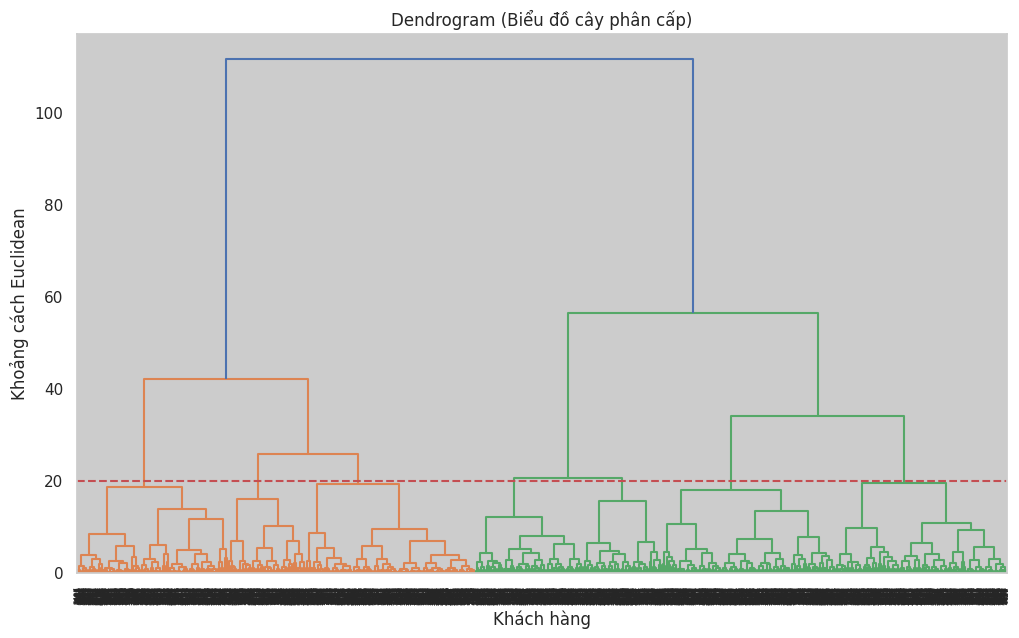

HƯỚNG DẪN: Nhìn vào đường nằm ngang dài nhất mà không bị các đường dọc cắt qua.
Đó là khoảng cách tối ưu để cắt số cụm.


In [ ]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12, 7))
plt.title('Dendrogram (Biểu đồ cây phân cấp)')
plt.xlabel('Khách hàng')
plt.ylabel('Khoảng cách Euclidean')

dendrogram = sch.dendrogram(sch.linkage(rfm_final_df, method='ward'))
plt.axhline(y=20, color='r', linestyle='--')
plt.show()

print("HƯỚNG DẪN: Nhìn vào đường nằm ngang dài nhất mà không bị các đường dọc cắt qua.")
print("Đó là khoảng cách tối ưu để cắt số cụm.")

#### 5.3.2 Định nghĩa class Hierarchical

In [ ]:
from scipy.spatial.distance import cdist

class MyHierarchicalClustering:
    def __init__(self, n_clusters=7, linkage='centroid'):
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.Z = None      
        self.labels = None   

    def fit(self, X):

        if hasattr(X, 'values'): X = X.values
        X = X.astype(float)

        n_samples = X.shape[0]

  
        clusters = {i: [i] for i in range(n_samples)}

        cluster_centers = {i: X[i] for i in range(n_samples)}

        self.Z = []

        next_cluster_id = n_samples

        print(f"Bắt đầu xây dựng Dendrogram từ {n_samples} điểm dữ liệu...")

        while len(clusters) > 1:
            current_ids = list(clusters.keys())

      
            centers = np.array([cluster_centers[cid] for cid in current_ids])

            dists = cdist(centers, centers, metric='euclidean')

            np.fill_diagonal(dists, np.inf)

            min_idx = np.unravel_index(np.argmin(dists), dists.shape)
            idx1, idx2 = min_idx

            id_merge_1 = current_ids[idx1]
            id_merge_2 = current_ids[idx2]
            dist_merge = dists[idx1, idx2]


            new_members = clusters[id_merge_1] + clusters[id_merge_2]
            clusters[next_cluster_id] = new_members


            n1 = len(clusters[id_merge_1])
            n2 = len(clusters[id_merge_2])
            new_center = (cluster_centers[id_merge_1] * n1 + cluster_centers[id_merge_2] * n2) / (n1 + n2)
            cluster_centers[next_cluster_id] = new_center


            self.Z.append([
                min(id_merge_1, id_merge_2),
                max(id_merge_1, id_merge_2),
                dist_merge,
                len(new_members)
            ])

            del clusters[id_merge_1]
            del clusters[id_merge_2]
            del cluster_centers[id_merge_1]
            del cluster_centers[id_merge_2]

            next_cluster_id += 1

            if len(self.Z) % 500 == 0:
                print(f"-> Đã thực hiện gộp {len(self.Z)} bước...")

        self.Z = np.array(self.Z)
        print("-> Hoàn tất xây dựng cây phân cấp!")
        return self

    def plot_dendrogram(self):
        """Hàm vẽ dùng kết quả Z tự tính"""
        if self.Z is None:
            print("Vui lòng chạy .fit() trước!")
            return

        from scipy.cluster.hierarchy import dendrogram
        plt.figure(figsize=(12, 6))
        plt.title('Dendrogram (Tự định nghĩa Linkage Matrix)')
        plt.xlabel('Chỉ số mẫu (Sample Index)')
        plt.ylabel('Khoảng cách gộp cụm')

        dendrogram(self.Z)
        plt.show()


#### 5.3.3 Huấn luyện mô hinh

Bắt đầu xây dựng Dendrogram từ 4191 điểm dữ liệu...
-> Đã thực hiện gộp 500 bước...
-> Đã thực hiện gộp 1000 bước...
-> Đã thực hiện gộp 1500 bước...
-> Đã thực hiện gộp 2000 bước...
-> Đã thực hiện gộp 2500 bước...
-> Đã thực hiện gộp 3000 bước...
-> Đã thực hiện gộp 3500 bước...
-> Đã thực hiện gộp 4000 bước...
-> Hoàn tất xây dựng cây phân cấp!


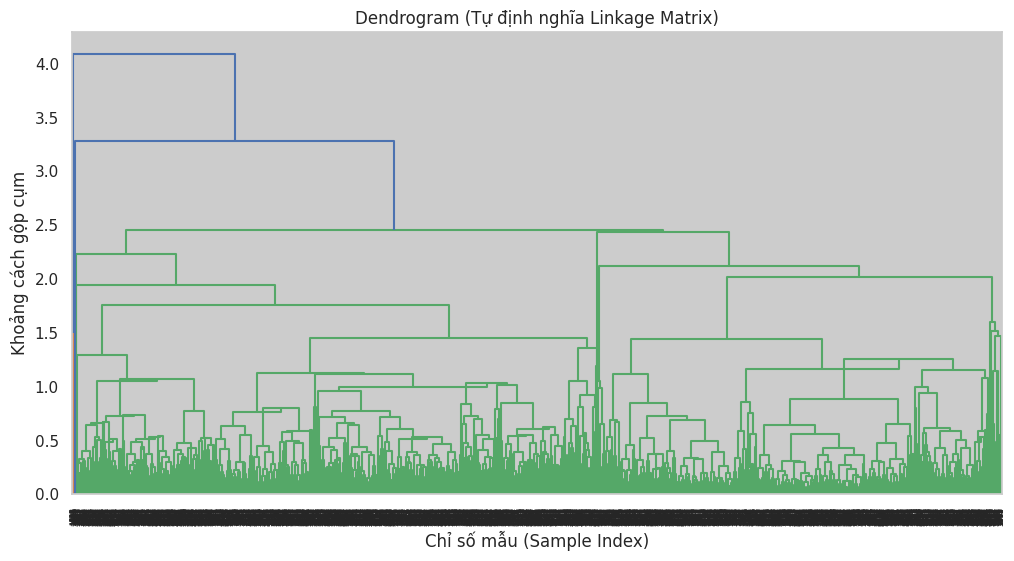

In [ ]:
X_sample = rfm_final_df

my_hc = MyHierarchicalClustering()
my_hc.fit(X_sample)

my_hc.plot_dendrogram()

#### 5.3.4 Chạy mô hình và cắt nhãn

In [ ]:
from scipy.cluster.hierarchy import fcluster
K_WANTED = 4


labels_hc = fcluster(my_hc.Z, t=K_WANTED, criterion='maxclust')

labels_hc = labels_hc - 1

rfm['Cluster_MyHC'] = labels_hc

print("\n--- KẾT QUẢ PHÂN CỤM TỪ MY_HIERARCHICAL ---")
print(rfm['Cluster_MyHC'].value_counts().sort_index())


--- KẾT QUẢ PHÂN CỤM TỪ MY_HIERARCHICAL ---
Cluster_MyHC
0      13
1    2352
2    1825
3       1
Name: count, dtype: int64


#### 5.3.5 Đánh giá mô hình

In [ ]:

X_eval = rfm_final_df.values
labels_eval = rfm['Cluster_MyHC']

print(f"Đang đánh giá mô hình trên {len(labels_eval)} mẫu dữ liệu...")


sil_score = silhouette_score(X_eval, labels_eval)


db_score = davies_bouldin_score(X_eval, labels_eval)


ch_score = calinski_harabasz_score(X_eval, labels_eval)

hc_metrics = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Value': [sil_score, db_score, ch_score],
    'Criterion': ['Max (Càng cao tốt)', 'Min (Càng thấp tốt)', 'Max (Càng cao tốt)']
})

print("\n--- KẾT QUẢ ĐÁNH GIÁ: MY_HIERARCHICAL CLUSTERING ---")
print(hc_metrics)


if 'Cluster_Manual' in rfm.columns:
    print("\n--- SO SÁNH VỚI K-MEANS ---")
    sil_kmeans = silhouette_score(X_eval, rfm['Cluster_Manual'])
    print(f"Silhouette K-Means: {sil_kmeans:.4f}")
    print(f"Silhouette Hierarchical: {sil_score:.4f}")

    if sil_score > sil_kmeans:
        print("-> Hierarchical Clustering cho kết quả TỐT HƠN K-Means.")
    elif sil_score < sil_kmeans:
        print("-> Hierarchical Clustering cho kết quả THẤP HƠN K-Means.")
    else:
        print("-> Hai mô hình cho kết quả TƯƠNG ĐƯƠNG nhau.")

Đang đánh giá mô hình trên 4191 mẫu dữ liệu...

--- KẾT QUẢ ĐÁNH GIÁ: MY_HIERARCHICAL CLUSTERING ---
                    Metric        Value            Criterion
0         Silhouette Score     0.334006   Max (Càng cao tốt)
1     Davies-Bouldin Index     0.693609  Min (Càng thấp tốt)
2  Calinski-Harabasz Index  1453.470224   Max (Càng cao tốt)

--- SO SÁNH VỚI K-MEANS ---
Silhouette K-Means: 0.4369
Silhouette Hierarchical: 0.3340
-> Hierarchical Clustering cho kết quả THẤP HƠN K-Means.


### Bước 5.4 : Mô hình esemble learning voting

Dùng KNN để giao tiếp với thuật toán DBScan và Hierical

In [ ]:
class MyKNN:
    def __init__(self, k=1):
        self.k = k 
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.astype(int)

    def predict(self, X_test):
        n_test = X_test.shape[0]
        y_pred = np.zeros(n_test, dtype=int)

        for i in range(n_test):
            distances = np.linalg.norm(self.X_train - X_test[i], axis=1)

            nearest_indices = np.argsort(distances)[:self.k]

            nearest_labels = self.y_train[nearest_indices]

            counts = np.bincount(nearest_labels)
            y_pred[i] = np.argmax(counts)

        return y_pred

#### 5.4.1 BaggingRandomAlgorithm

In [ ]:
import random

class BaggingRandomAlgorithm:
    def __init__(self, n_estimators=10, k_target=4, subsample_ratio=0.7):
        self.n_estimators = n_estimators
        self.k_target = k_target
        self.subsample_ratio = subsample_ratio
        self.final_labels = None

        self.configs = {
            'kmeans': {'k': k_target},
            'dbscan': {'eps': 0.5, 'min_samples': 10},
            'hierarchical': {'n_clusters': k_target}
        }

    def fit_predict(self, X_df):
        X_values = X_df.values
        n_samples = len(X_values)

        votes_matrix = np.zeros((n_samples, self.n_estimators), dtype=int)

        print(f"--- BẮT ĐẦU BAGGING ĐA THUẬT TOÁN ({self.n_estimators} LẦN) ---")

        for i in range(self.n_estimators):
            algo_type = random.choice(['kmeans', 'dbscan', 'hierarchical'])

            n_sub = int(n_samples * self.subsample_ratio)
            random_idx = np.random.choice(n_samples, n_sub, replace=False)
            X_subset = X_values[random_idx]

            labels_all = None

            if algo_type == 'kmeans':
                model = MyKMeans(k=self.configs['kmeans']['k'])
                model.fit(X_subset)
                labels_all = model.predict(X_values)

            elif algo_type == 'dbscan':
                cfg = self.configs['dbscan']
                model = MyDBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'])
                model.fit(X_subset)

                valid_mask = model.labels != -1
                if sum(valid_mask) > 0:
                    knn = MyKNN(k=1) 
                    knn.fit(X_subset[valid_mask], model.labels[valid_mask])
                    labels_all = knn.predict(X_values)
                else:
                    labels_all = np.zeros(n_samples, dtype=int)

            elif algo_type == 'hierarchical':

                model = MyHierarchicalClustering()
                model.fit(X_subset) 

                labels_subset = fcluster(model.Z, t=self.configs['hierarchical']['n_clusters'], criterion='maxclust')
                labels_subset = labels_subset - 1

                knn = MyKNN(k=1)
                knn.fit(X_subset, labels_subset)
                labels_all = knn.predict(X_values)

   
            df_temp = pd.DataFrame({'Label': labels_all, 'Monetary': X_values[:, 2]})
            mean_monetary = df_temp.groupby('Label')['Monetary'].mean().sort_values()

            sorted_labels = mean_monetary.index.tolist()
            map_dict = {old: new for new, old in enumerate(sorted_labels)}

            aligned_labels = np.array([map_dict[l] for l in labels_all])

            votes_matrix[:, i] = aligned_labels
            print(f"Iter {i+1}: Dùng {algo_type.upper()}. Đã xong.")

        print("--- ĐANG TỔNG HỢP PHIẾU BẦU ---")
        final_vote, _ = stats.mode(votes_matrix, axis=1, keepdims=True)
        self.final_labels = final_vote.flatten()

        return self.final_labels

In [ ]:

bagging_random = BaggingRandomAlgorithm(n_estimators=5, k_target=2, subsample_ratio=0.6)

rfm['Cluster_Random_Ensemble'] = bagging_random.fit_predict(rfm_final_df)

print("\n--- KẾT QUẢ CUỐI CÙNG (ENSEMBLE TỰ XÂY 100%) ---")
print(rfm['Cluster_Random_Ensemble'].value_counts().sort_index())

--- BẮT ĐẦU BAGGING ĐA THUẬT TOÁN (5 LẦN) ---
Iter 1: Dùng KMEANS. Đã xong.
Iter 2: Dùng KMEANS. Đã xong.
Iter 3: Dùng KMEANS. Đã xong.
Đang chạy DBSCAN (eps=0.5, min_samples=10)...
--> Hoàn tất! Tìm thấy 3 cụm (không tính Nhiễu).
Iter 4: Dùng DBSCAN. Đã xong.
Bắt đầu xây dựng Dendrogram từ 2514 điểm dữ liệu...
-> Đã thực hiện gộp 500 bước...
-> Đã thực hiện gộp 1000 bước...
-> Đã thực hiện gộp 1500 bước...
-> Đã thực hiện gộp 2000 bước...
-> Đã thực hiện gộp 2500 bước...
-> Hoàn tất xây dựng cây phân cấp!
Iter 5: Dùng HIERARCHICAL. Đã xong.
--- ĐANG TỔNG HỢP PHIẾU BẦU ---

--- KẾT QUẢ CUỐI CÙNG (ENSEMBLE TỰ XÂY 100%) ---
Cluster_Random_Ensemble
0    2263
1    1928
Name: count, dtype: int64


In [ ]:
labels_final = rfm['Cluster_Random_Ensemble']
X_eval = rfm_final_df.values

print("Đang tính toán các chỉ số đánh giá cho mô hình Ensemble...")

sil_score = silhouette_score(X_eval, labels_final)

db_score = davies_bouldin_score(X_eval, labels_final)

ch_score = calinski_harabasz_score(X_eval, labels_final)

ensemble_metrics = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Value': [sil_score, db_score, ch_score],
    'Ideal': ['Càng cao càng tốt (Max 1)', 'Càng thấp càng tốt (Min 0)', 'Càng cao càng tốt']
})

print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ENSEMBLE ---")
print(ensemble_metrics)


print("\n--- PHÂN PHỐI KHÁCH HÀNG ---")
print(labels_final.value_counts().sort_index())

Đang tính toán các chỉ số đánh giá cho mô hình Ensemble...

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ENSEMBLE ---
                    Metric        Value                       Ideal
0         Silhouette Score     0.436765   Càng cao càng tốt (Max 1)
1     Davies-Bouldin Index     0.865537  Càng thấp càng tốt (Min 0)
2  Calinski-Harabasz Index  4749.998886           Càng cao càng tốt

--- PHÂN PHỐI KHÁCH HÀNG ---
Cluster_Random_Ensemble
0    2263
1    1928
Name: count, dtype: int64


## Bước 6: Mô hình đề xuất AutoMultiStageClustering

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

class AutoMultiStageClustering:
    def __init__(self, k_target=2, random_state=42):
        self.random_state = random_state
        self.pca_model = None
        self.X_pca = None
        self.best_model_name = None
        self.best_model_params = None
        self.final_model = None
        self.labels = None
        self.k_target = k_target

        self.model_configs = {
            'kmeans': {'class': MyKMeans, 'params': {'k': k_target}},
            'dbscan': {'class': MyDBSCAN, 'params': {'eps': 0.5, 'min_samples': 10}},
            'hierarchical': {'class': MyHierarchicalClustering, 'params': {'n_clusters': k_target}}
        }

    def step1_pca_transform(self, X, variance_threshold=0.90):
        print(f"\n--- BƯỚC 1: PCA - Nén không gian dữ liệu (Giữ lại > {variance_threshold*100}%) ---")
        if hasattr(X, 'values'):
            X = X.values

        self.pca_model = PCA(n_components=variance_threshold, random_state=self.random_state)
        self.X_pca = self.pca_model.fit_transform(X)

        explained_var = np.sum(self.pca_model.explained_variance_ratio_)
        n_components = self.pca_model.n_components_

        print(f"-> Số chiều gốc: {X.shape[1]}")
        print(f"-> Số chiều sau PCA: {n_components}")
        print(f"-> Tổng phương sai giữ lại: {explained_var:.4f}")

        if n_components == 2:
            plt.figure(figsize=(8, 6))
            plt.scatter(self.X_pca[:, 0], self.X_pca[:, 1], alpha=0.5, c='gray')
            plt.title('Dữ liệu trong không gian PCA (2D)')
            plt.xlabel('Principal Component 1')
            plt.ylabel('Principal Component 2')
            plt.show()
        elif n_components == 3:
            try:
                fig = plt.figure(figsize=(10, 8))
                ax = fig.add_subplot(111, projection='3d')
                ax.scatter(self.X_pca[:, 0], self.X_pca[:, 1], self.X_pca[:, 2], alpha=0.5, c='gray')
                ax.set_title('Dữ liệu trong không gian PCA (3D)')
                ax.set_xlabel('Principal Component 1')
                ax.set_ylabel('Principal Component 2')
                ax.set_zlabel('Principal Component 3')
                plt.show()
            except Exception as e:
                print(f"Cảnh báo: Không thể vẽ biểu đồ 3D. Lỗi: {e}")

        return self.X_pca

    def step2_lazy_screening(self):
        print("\n--- BƯỚC 2: Sàng lọc mô hình sơ bộ (Lazy Clustering) ---")
        results = []

        for name, config in self.model_configs.items():
            try:
                ModelClass = config['class']
                model_params = config['params'].copy()

                model = None
                labels = None

                if name == 'kmeans':
                    model = ModelClass(**model_params)
                    model.fit(self.X_pca)
                    labels = model.labels
                elif name == 'dbscan':
                    model = ModelClass(**model_params)
                    model.fit(self.X_pca)
                    labels = model.labels
                elif name == 'hierarchical':
                    model = ModelClass()
                    model.fit(self.X_pca)
                    if model.Z is not None and model.Z.shape[0] > 0:
                        labels = fcluster(model.Z, t=model_params['n_clusters'], criterion='maxclust')
                        labels = labels - 1
                    else:
                        raise ValueError("Hierarchical model did not produce a valid linkage matrix.")

                if labels is None:
                    raise ValueError(f"Model {name} did not produce any labels.")

                unique_labels = np.unique(labels)
                n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

                if n_clusters < 2:
                    sil = -1
                    print(f"-> {name}: Thất bại (Chỉ tìm thấy {n_clusters} cụm hoặc không đủ cụm)")
                else:
                    if name == 'dbscan' and -1 in unique_labels:
                        mask = labels != -1
                        if np.sum(mask) > 1 and len(np.unique(labels[mask])) > 1: 
                             sil = silhouette_score(self.X_pca[mask], labels[mask])
                        else:
                             sil = -1
                    else:
                        sil = silhouette_score(self.X_pca, labels)

                    print(f"-> {name}: Silhouette Score = {sil:.4f}")

                results.append({'Model': name, 'Score': sil, 'Labels': labels, 'Model_Instance': model})

            except Exception as e:
                print(f"-> {name}: Lỗi ({str(e)})")
                results.append({'Model': name, 'Score': -2, 'Labels': np.full(self.X_pca.shape[0], -1), 'Model_Instance': None})

        results_df = pd.DataFrame(results).sort_values(by='Score', ascending=False)
        if not results_df.empty and results_df.iloc[0]['Score'] > -2: 
            self.best_model_name = results_df.iloc[0]['Model']
            self.final_model = results_df.iloc[0]['Model_Instance'] 
            self.labels = results_df.iloc[0]['Labels'] 
            self.best_model_params = self.model_configs[self.best_model_name]['params'].copy()
            print(f"\n=> MÔ HÌNH TIỀM NĂNG NHẤT: {self.best_model_name} (Silhouette Score = {results_df.iloc[0]['Score']:.4f})")
        else:
            self.best_model_name = "None_Found"
            self.final_model = None
            self.labels = np.full(self.X_pca.shape[0], -1)
            self.best_model_params = {}
            print("\n=> KHÔNG CÓ MÔ HÌNH NÀO THÀNH CÔNG TRONG BƯỚC SÀNG LỌC SƠ BỘ.")

        return self.best_model_name

    def step3_optimization(self, k_range=range(2, 11)):
        print(f"\n--- BƯỚC 3: Tối ưu hóa siêu tham số cho {self.best_model_name} ---")

        best_score = -1
        best_params = {}
        best_labels = np.full(self.X_pca.shape[0], -1)

        if self.best_model_name == "None_Found":
            print("Không thể tối ưu hóa vì không có mô hình nào được chọn.")
            self.labels = np.full(self.X_pca.shape[0], -1)
            return self.labels

        if self.best_model_name == 'kmeans' or self.best_model_name == 'hierarchical':
            print(f"-> Đang chạy Elbow Method & Silhouette Analysis (K từ {k_range.start} đến {k_range.stop-1})...")

            sil_scores = []
            wcss = [] 

            for k in k_range:
                labels = None
                model_instance = None

                try:
                    if self.best_model_name == 'kmeans':
                        model = MyKMeans(k=self.configs['kmeans']['k'])
                        model_instance.fit(self.X_pca)
                        labels = model_instance.labels
                        if model_instance.inertia_ is not None:
                            wcss.append(model_instance.inertia_)

                    elif self.best_model_name == 'hierarchical':
                        model_instance = MyHierarchicalClustering()
                        model_instance.fit(self.X_pca)
                        if model_instance.Z is not None and model_instance.Z.shape[0] > 0:
                            labels = fcluster(model_instance.Z, t=k, criterion='maxclust')
                            labels = labels - 1 
                        else:
                            raise ValueError("Hierarchical model did not produce a valid linkage matrix for K.")

                    if labels is not None and len(np.unique(labels)) > 1:
                        score = silhouette_score(self.X_pca, labels)
                        sil_scores.append(score)

                        if score > best_score:
                            best_score = score
                            best_params = {'n_clusters': k}
                            best_labels = labels
                            self.final_model = model_instance 
                    else:
                        sil_scores.append(-1) 
                except Exception as e:
                    print(f"   Lỗi khi tối ưu K={k} cho {self.best_model_name}: {e}")
                    sil_scores.append(-1)

            if sil_scores:
                plt.figure(figsize=(10, 4))

                plt.subplot(1, 2, 1)
                plt.plot(k_range, sil_scores, 'bo-')
                plt.title(f'Silhouette Score theo K ({self.best_model_name})')
                plt.xlabel('Số cụm K')
                plt.ylabel('Silhouette Score')

                if self.best_model_name == 'kmeans' and wcss:
                    plt.subplot(1, 2, 2)
                    plt.plot(k_range[:len(wcss)], wcss, 'rx-')
                    plt.title('Elbow Method (WCSS)')
                    plt.xlabel('Số cụm K')

                plt.tight_layout()
                plt.show()

        elif self.best_model_name == 'dbscan':
            print("-> Đang Grid Search tìm Eps tối ưu cho DBSCAN...")
            eps_values = np.arange(0.3, 1.1, 0.1)

            for eps in eps_values:
                try:
                    model_instance = MyDBSCAN(eps=eps, min_samples=self.best_model_params.get('min_samples', 5))
                    model_instance.fit(self.X_pca)
                    labels = model_instance.labels

                    mask = labels != -1
                    unique_valid_labels = np.unique(labels[mask])

                    if np.sum(mask) > 1 and len(unique_valid_labels) > 1:
                        score = silhouette_score(self.X_pca[mask], labels[mask])
                    else:
                        score = -1

                    print(f"   Eps={eps:.1f} -> Score={score:.4f}")

                    if score > best_score:
                        best_score = score
                        best_params = {'eps': eps, 'min_samples': self.best_model_params.get('min_samples', 5)}
                        best_labels = labels
                        self.final_model = model_instance 
                except Exception as e:
                    print(f"   Lỗi khi tối ưu Eps={eps:.1f} cho DBSCAN: {e}")
                    pass
        else:
            print(f"Không có chiến lược tối ưu hóa cho mô hình: {self.best_model_name}. Sử dụng kết quả từ bước sàng lọc sơ bộ.")
            best_labels = self.labels if self.labels is not None else np.full(self.X_pca.shape[0], -1)
            if best_labels is not None and len(np.unique(best_labels)) > 1:
                best_score = silhouette_score(self.X_pca, best_labels)
            else:
                best_score = -1

        self.best_model_params = best_params
        self.labels = best_labels
        if self.labels is None:
             self.labels = np.full(self.X_pca.shape[0], -1)


        print(f"\n=> KẾT QUẢ TỐI ƯU: {self.best_model_name}")
        print(f"   Tham số: {self.best_model_params}")
        print(f"   Silhouette Score cao nhất: {best_score:.4f}")

        return self.labels

    def run(self, X):
        self.step1_pca_transform(X)
        self.step2_lazy_screening()
        self.step3_optimization()
        return self.labels


--- BƯỚC 1: PCA - Nén không gian dữ liệu (Giữ lại > 90.0%) ---
-> Số chiều gốc: 3
-> Số chiều sau PCA: 2
-> Tổng phương sai giữ lại: 0.9304


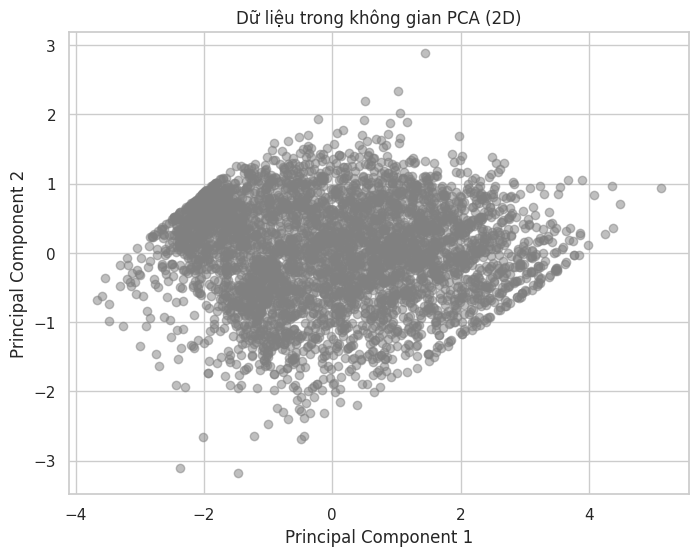


--- BƯỚC 2: Sàng lọc mô hình sơ bộ (Lazy Clustering) ---
-> kmeans: Silhouette Score = 0.4718
Đang chạy DBSCAN (eps=0.5, min_samples=10)...
--> Hoàn tất! Tìm thấy 1 cụm (không tính Nhiễu).
-> dbscan: Thất bại (Chỉ tìm thấy 1 cụm hoặc không đủ cụm)
Bắt đầu xây dựng Dendrogram từ 4191 điểm dữ liệu...
-> Đã thực hiện gộp 500 bước...
-> Đã thực hiện gộp 1000 bước...
-> Đã thực hiện gộp 1500 bước...
-> Đã thực hiện gộp 2000 bước...
-> Đã thực hiện gộp 2500 bước...
-> Đã thực hiện gộp 3000 bước...
-> Đã thực hiện gộp 3500 bước...
-> Đã thực hiện gộp 4000 bước...
-> Hoàn tất xây dựng cây phân cấp!
-> hierarchical: Silhouette Score = 0.5591

=> MÔ HÌNH TIỀM NĂNG NHẤT: hierarchical (Silhouette Score = 0.5591)

--- BƯỚC 3: Tối ưu hóa siêu tham số cho hierarchical ---
-> Đang chạy Elbow Method & Silhouette Analysis (K từ 2 đến 10)...
Bắt đầu xây dựng Dendrogram từ 4191 điểm dữ liệu...
-> Đã thực hiện gộp 500 bước...
-> Đã thực hiện gộp 1000 bước...
-> Đã thực hiện gộp 1500 bước...
-> Đã thực hiệ

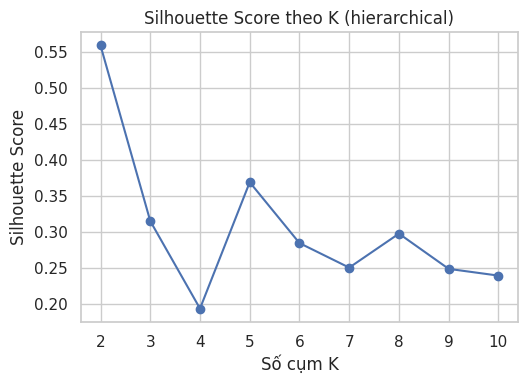


=> KẾT QUẢ TỐI ƯU: hierarchical
   Tham số: {'n_clusters': 2}
   Silhouette Score cao nhất: 0.5591

--- PHÂN PHỐI KHÁCH HÀNG (AUTO PCA MODEL) ---
Cluster_AutoPCA
0    4190
1       1
Name: count, dtype: int64
Calinski-Harabasz Index: 9.74


In [ ]:
auto_clustering = AutoMultiStageClustering(k_target=2)

final_labels_auto = auto_clustering.run(rfm_final_df)

rfm['Cluster_AutoPCA'] = final_labels_auto

print("\n--- PHÂN PHỐI KHÁCH HÀNG (AUTO PCA MODEL) ---")
print(rfm['Cluster_AutoPCA'].value_counts().sort_index())

from sklearn.metrics import calinski_harabasz_score
if hasattr(rfm_final_df, 'values'):
    X_eval = rfm_final_df.values
else:
    X_eval = rfm_final_df

mask = final_labels_auto != -1
if np.sum(mask) > 0 and len(np.unique(final_labels_auto[mask])) > 1:
    ch_score = calinski_harabasz_score(X_eval[mask], final_labels_auto[mask])
    print(f"Calinski-Harabasz Index: {ch_score:.2f}")
else:
    print("Không đủ cụm hoặc mẫu để tính Calinski-Harabasz Index sau khi loại bỏ nhiễu.")

## Xuất file pkl

In [ ]:
import joblib
import pandas as pd
import os
from datetime import datetime

if 'rfm' in locals():
    final_df = rfm.copy()
elif 'rfm_final_df' in locals():
    final_df = rfm_final_df.copy()
else:
    raise ValueError("Không tìm thấy biến dataframe kết quả (rfm hoặc rfm_final_df)")

target_cols = ['Recency', 'Frequency', 'Monetary', 'Cluster_Random_Ensemble']

if final_df.index.name == 'CustomerID':
    final_df = final_df.reset_index()
    target_cols.insert(0, 'CustomerID')
elif 'CustomerID' in final_df.columns:
    target_cols.insert(0, 'CustomerID')

available_cols = [c for c in target_cols if c in final_df.columns]
export_df = final_df[available_cols]

cluster_col = 'Cluster_Random_Ensemble'
summary_df = export_df.groupby(cluster_col)[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

artifacts = {
    "data": export_df.to_dict(orient='records'),    
    "summary": summary_df.to_dict(orient='records'), 
    "metadata": {
        "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "total_customers": len(export_df),
        "cluster_col": cluster_col
    }
}

os.makedirs("artifacts", exist_ok=True)
save_path = "artifacts/result_dashboard.pkl"
joblib.dump(artifacts, save_path)

print(f"ĐÃ XUẤT FILE CHUẨN TẠI: {save_path}")
print("File này chứa dữ liệu thô (Dict), không cần scikit-learn để mở.")

ĐÃ XUẤT FILE CHUẨN TẠI: artifacts/result_dashboard.pkl
File này chứa dữ liệu thô (Dict), không cần scikit-learn để mở.
